## Imports and setup

In [1]:
# Import required libraries
import os
import time
import torch
import numpy as np
import pandas as pd
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

import networkx as nx
from scipy.stats import pearsonr
from functools import partial
from pathlib import Path
from scipy.spatial.distance import pdist
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler # Do NOT standardize features!
from torch.utils.data import Dataset, DataLoader
from sklearn.random_projection import johnson_lindenstrauss_min_dim, GaussianRandomProjection

import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Device detection and setup
def get_device():
    """Detect and return the best available device for PyTorch."""
    if torch.cuda.is_available():
        device = torch.device('cuda')
        print(f"Using CUDA device: {torch.cuda.get_device_name(0)}")
        print(f"CUDA version: {torch.version.cuda}")
        print(f"GPU memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
    elif hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
        device = torch.device('mps')
        print("Using MPS (Metal Performance Shaders) device")
    else:
        device = torch.device('cpu')
        print("Using CPU device")
    
    print(f"PyTorch version: {torch.__version__}")
    return device

# Set device
device = get_device()


Using MPS (Metal Performance Shaders) device
PyTorch version: 2.8.0


## Using transcriptomics as the embeddings

In [2]:
# Configuration
CONFIG_TRANSCRIPTOMICS = {
    'embedding_dim': 512,  # D - configurable embedding dimension (will be updated based on JL lemma)
    'hidden_dim': 256,      # Hidden dimension for Q/K projections
    'batch_size': 16,       # Batch size for training
    'learning_rate': 1e-3,  # Learning rate
    'num_samples': 1600,     # Total number of augmented samples (different random projections)
    'use_attention_scores': False, # Use attention scores instead of weights
    'attn_dropout': 0.0,  # Dropout for attention mask beyond diagonal (self) masking
    'consistency_weight': 0.0,  # Weight for batch consistency regularization
    'consistency_type': 'variance',  # 'variance' (default) or 'frobenius'
    'dataset_type': 'random_projection',  # Options: 'random_projection' or 'feature_subset'
    'jl_epsilon': 0.3,     # JL lemma epsilon when using random_projection dataset
    'n_layers': 3,           # Number of decoder blocks (1 = shallow, >1 = deep)
    'mlp_expansion': 4,      # MLP hidden layer expansion factor
    'dropout': 0.1,          # Dropout rate for MLP layers
}

print("Configuration:")
for key, value in CONFIG_TRANSCRIPTOMICS.items():
    print(f"  {key}: {value}")
print(f"\nDevice: {device}")

Configuration:
  embedding_dim: 512
  hidden_dim: 256
  batch_size: 16
  learning_rate: 0.001
  num_samples: 1600
  use_attention_scores: False
  attn_dropout: 0.0
  consistency_weight: 0.0
  consistency_type: variance
  dataset_type: random_projection
  jl_epsilon: 0.3
  n_layers: 3
  mlp_expansion: 4
  dropout: 0.1

Device: mps


## Data Preparation and Embedding Generation

We start by loading the single-cell transcriptome data. This dataset contains gene expression data for 22,469 genes across 130 neuron classes, providing much more granular resolution than bulk-sorted data.

Our approach:
1. Load and preprocess the transcriptome data
2. Apply log1p transformation and standardization
3. Optionally, performe PCA to reduce dimensionality and visualization
4. Generate initial (N, D) embedding matrix where N=130 neuron classes


In [3]:
# Load GSE136049 neuron-class transcriptome (preferring log-normalized means)
transcriptomics_data_dir = 'data/transcriptomics/Single Cell Seq/GEO (GSE 136049)'
lognorms_path = f'{transcriptomics_data_dir}/GSE136049_genes_by_neurons_lognorm_means.csv'
counts_path    = f'{transcriptomics_data_dir}/GSE136049_genes_by_neurons_counts.csv'
preferred_path = lognorms_path

if os.path.exists(preferred_path):
    df = pd.read_csv(preferred_path, index_col=0)
    used = preferred_path
    X_ = df.T.values  # neurons x genes
else:
    assert os.path.exists(counts_path), "Missing GSE136049 CSVs; run load_data.ipynb first."
    df = pd.read_csv(counts_path, index_col=0)
    used = counts_path
    # counts → log1p before standardization
    X_ = np.log1p(df.T.values)

neuron_labels = df.columns.tolist()
transcript_names = df.index.tolist()
print(f"Loaded: {used}")
print(f"Original table shape (genes x neuron_labels): {df.shape}")
print(f"Transposed to (neurons x genes): {X_.shape}")
print(f"Neuron classes (sample 10): {neuron_labels[:10]}")
print(f"Genes (sample 10): {transcript_names[:10]}")

X_original = X_
print(f"X_original shape: {X_original.shape}")
# NOTE: Do NOT standardize features (genes) with StandardScaler. It strips away the variance imformation.
print(f"Without standardization {X_original.mean(axis=0).shape} genes (first 5) \n\tmean: {X_original.mean(axis=0)[:5]}, \n\tstd: {X_original.std(axis=0)[:5]}")

N_neurons = len(neuron_labels)
assert N_neurons == X_original.shape[0]
print(f"Number of neuron classes: {N_neurons}")
print(f"Neuron classes: {neuron_labels}")


Loaded: data/transcriptomics/Single Cell Seq/GEO (GSE 136049)/GSE136049_genes_by_neurons_lognorm_means.csv
Original table shape (genes x neuron_labels): (22469, 130)
Transposed to (neurons x genes): (130, 22469)
Neuron classes (sample 10): ['ADA', 'ADE', 'ADF', 'ADL', 'AFD', 'AIA', 'AIB', 'AIM', 'AIN', 'AIY']
Genes (sample 10): ['WBGene00010957', 'WBGene00010958', 'WBGene00014454', 'WBGene00010959', 'WBGene00010960', 'WBGene00010961', 'WBGene00000829', 'WBGene00010962', 'WBGene00010963', 'WBGene00010964']
X_original shape: (130, 22469)
Without standardization (22469,) genes (first 5) 
	mean: [2.87590796 1.01728045 0.8490579  1.07566784 1.96477043], 
	std: [0.92014032 0.41039817 0.42220107 0.57693753 0.81696442]
Number of neuron classes: 130
Neuron classes: ['ADA', 'ADE', 'ADF', 'ADL', 'AFD', 'AIA', 'AIB', 'AIM', 'AIN', 'AIY', 'AIZ', 'ALA', 'ALM', 'ALN', 'AQR', 'AS', 'ASEL', 'ASER', 'ASG', 'ASH', 'ASI', 'ASJ', 'ASK', 'AUA', 'AVA', 'AVB', 'AVD', 'AVE', 'AVF', 'AVG', 'AVH', 'AVJ', 'AVK', 

#### By morphological criteria, the 302 neurons of the worm are classified into 118 distinct types, and from the database of reporter transgene expression patterns, most of these are postulated to have unique molecular signatures.

File used was obtained from the [supplemental information](https://www.sciencedirect.com/science/article/pii/S096098221631212X?via%3Dihub#app2) of this paper:
   >  Hobert, O., Glenwinkel, L. & White, J. Revisiting Neuronal Cell Type Classification in Caenorhabditis elegans. Curr. Biol. 26, R1197–R1203 (2016).
  


In [4]:
# Load neuron metadata from supplementary data file
neuron_metadata_df = pd.read_excel('data/1-s2.0-S096098221631212X-mmc2.xlsx', 
                                    sheet_name='List_with_genes.txt',
                                    header=3,    # Headers are on row 4 (0-based index 3)
                                    nrows=302,   # Data is in rows 5-306 (302 rows total)
                                    usecols=[0,1,2,3]  # Only first 4 columns
                                 ).ffill() # Forward fill empty cells to handle merged-cell-like data

print(f"Loaded neuron metadata: {neuron_metadata_df.shape}")
print(f"Columns: {neuron_metadata_df.columns.tolist()}")
print(f"Sample rows:")
print(neuron_metadata_df.head())

# Create lookup dictionaries mapping both neuron labels and classes to neurotransmitter
label_to_neurotransmitter = dict(zip(neuron_metadata_df['Class member'], 
                                    neuron_metadata_df['Neurotransmitter identity']))
class_to_neurotransmitter = dict(zip(neuron_metadata_df['Neuron class'].unique(),
                                    neuron_metadata_df.groupby('Neuron class')['Neurotransmitter identity'].first()))

# Create lookup dictionary mapping labels to their neuron class
label_to_class = dict(zip(neuron_metadata_df['Class member'],
                         neuron_metadata_df['Neuron class']))

# No type information in this dataset, so we'll remove those dictionaries
print(f"\nLookup dictionaries created:")
print(f"  label_to_neurotransmitter: {len(label_to_neurotransmitter)} entries")
print(f"  class_to_neurotransmitter: {len(class_to_neurotransmitter)} entries") 
print(f"  label_to_class: {len(label_to_class)} entries")


Loaded neuron metadata: (302, 4)
Columns: ['Neuron class', 'Class member', 'Lineage', 'Neurotransmitter identity']
Sample rows:
  Neuron class Class member        Lineage Neurotransmitter identity
0          ADA         ADAL  AB.plapaaaapp                       Glu
1          ADA         ADAR  AB.prapaaaapp                       Glu
2          ADE         ADEL  AB.plapaaaapa                        DA
3          ADE         ADER  AB.prapaaaapa                        DA
4          ADF         ADFL   AB.alpppppaa                       Ach

Lookup dictionaries created:
  label_to_neurotransmitter: 302 entries
  class_to_neurotransmitter: 118 entries
  label_to_class: 302 entries


In [5]:
# Map each neuron in neuron_labels to neurotransmitter and class
neuron_neurotransmitters = []
neuron_classes = []

for neuron in neuron_labels:
    # First try exact match in label dictionary
    if neuron in label_to_neurotransmitter:
        nt = label_to_neurotransmitter[neuron]
        cls = label_to_class[neuron]
    # Then try match in class dictionary
    elif neuron in class_to_neurotransmitter:
        nt = class_to_neurotransmitter[neuron]
        cls = neuron  # The neuron label is already a class name
    else:
        # Mark as unknown if not found
        nt = '<Missing>'
        cls = '<Missing>'
    
    neuron_neurotransmitters.append(nt)
    neuron_classes.append(cls)

# Convert to arrays
neuron_neurotransmitters = np.array(neuron_neurotransmitters)
neuron_classes = np.array(neuron_classes)

print(f"\nNeuron metadata mapping:")
print(f"Total neurons: {len(neuron_labels)}")
print(f"Unique neurotransmitters: {np.unique(neuron_neurotransmitters)}")
print(f"Unique classes: {np.unique(neuron_classes)}")
print(f"Unknown neurotransmitters: {(neuron_neurotransmitters == '<Missing>').sum()}")
print(f"Unknown classes: {(neuron_classes == '<Missing>').sum()}")

# Show some examples of the mapping
print(f"\nSample mappings:")
for i in range(min(10, len(neuron_labels))):
    print(f"  {neuron_labels[i]} -> NT: {neuron_neurotransmitters[i]}, Class: {neuron_classes[i]}")



Neuron metadata mapping:
Total neurons: 130
Unique neurotransmitters: ['5HT' '<Missing>' 'ACh' 'ACh (minor)' 'Ach' 'DA' 'GABA' 'Glu' 'Glu & 5HT'
 'Octopamine' 'Unknown (orphan)' 'unknown MA (cat-1)']
Unique classes: ['<Missing>' 'ADA' 'ADE' 'ADF' 'ADL' 'AFD' 'AIA' 'AIB' 'AIM' 'AIN' 'AIY'
 'AIZ' 'ALA' 'ALM' 'ALN' 'AQR' 'AS' 'ASE' 'ASG' 'ASH' 'ASI' 'ASJ' 'ASK'
 'AUA' 'AVA' 'AVB' 'AVD' 'AVE' 'AVF' 'AVG' 'AVH' 'AVJ' 'AVK' 'AVL' 'AVM'
 'AWA' 'AWB' 'BAG' 'BDU' 'CAN' 'CEP' 'DA' 'DB' 'DVA' 'DVB' 'DVC' 'FLP'
 'HSN' 'I1' 'I2' 'I3' 'I4' 'I5' 'I6' 'IL1' 'LUA' 'M1' 'M2' 'M3' 'M4' 'M5'
 'MC' 'MI' 'NSM' 'OLL' 'OLQ' 'PDA' 'PDB' 'PDE' 'PHA' 'PHB' 'PHC' 'PLM'
 'PLN' 'PQR' 'PVC' 'PVD' 'PVM' 'PVN' 'PVP' 'PVQ' 'PVR' 'PVT' 'PVW' 'RIA'
 'RIB' 'RIC' 'RID' 'RIF' 'RIG' 'RIH' 'RIM' 'RIP' 'RIR' 'RIS' 'RIV' 'RMF'
 'RMG' 'RMH' 'SAA' 'SAB' 'SDQ' 'SIA' 'SIB' 'SMB' 'SMD' 'URA' 'URB' 'URX'
 'URY' 'VA' 'VB' 'VC']
Unknown neurotransmitters: 15
Unknown classes: 15

Sample mappings:
  ADA -> NT: Glu, Class: ADA
  ADE -> N

Applying PCA preprocessing to reduce dimensions and visualize data...
Original data shape: (130, 22469)
Using 129 PCA components (max allowable: 129)
PCA preprocessed data shape: (130, 129)
Explained variance ratio (first 10 components): [0.1010845  0.0711716  0.04499718 0.04002918 0.03708121 0.03003903
 0.02515988 0.02317245 0.02031772 0.01915597]
Total explained variance: 1.0000


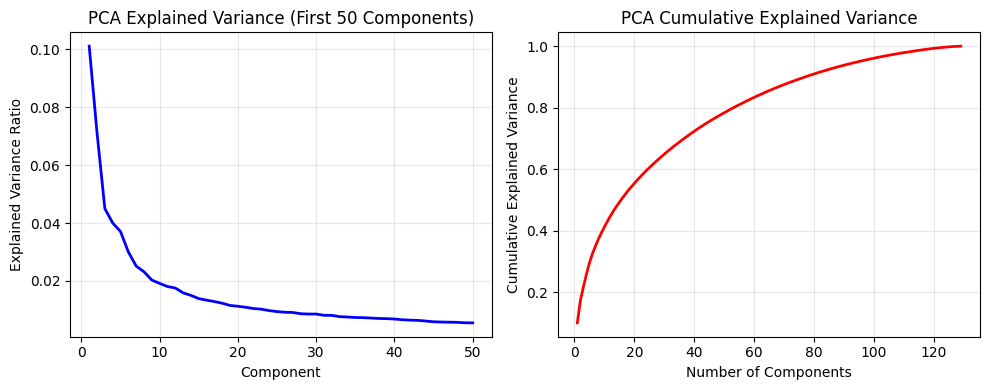

Plotting first two PCA components with metadata coloring...


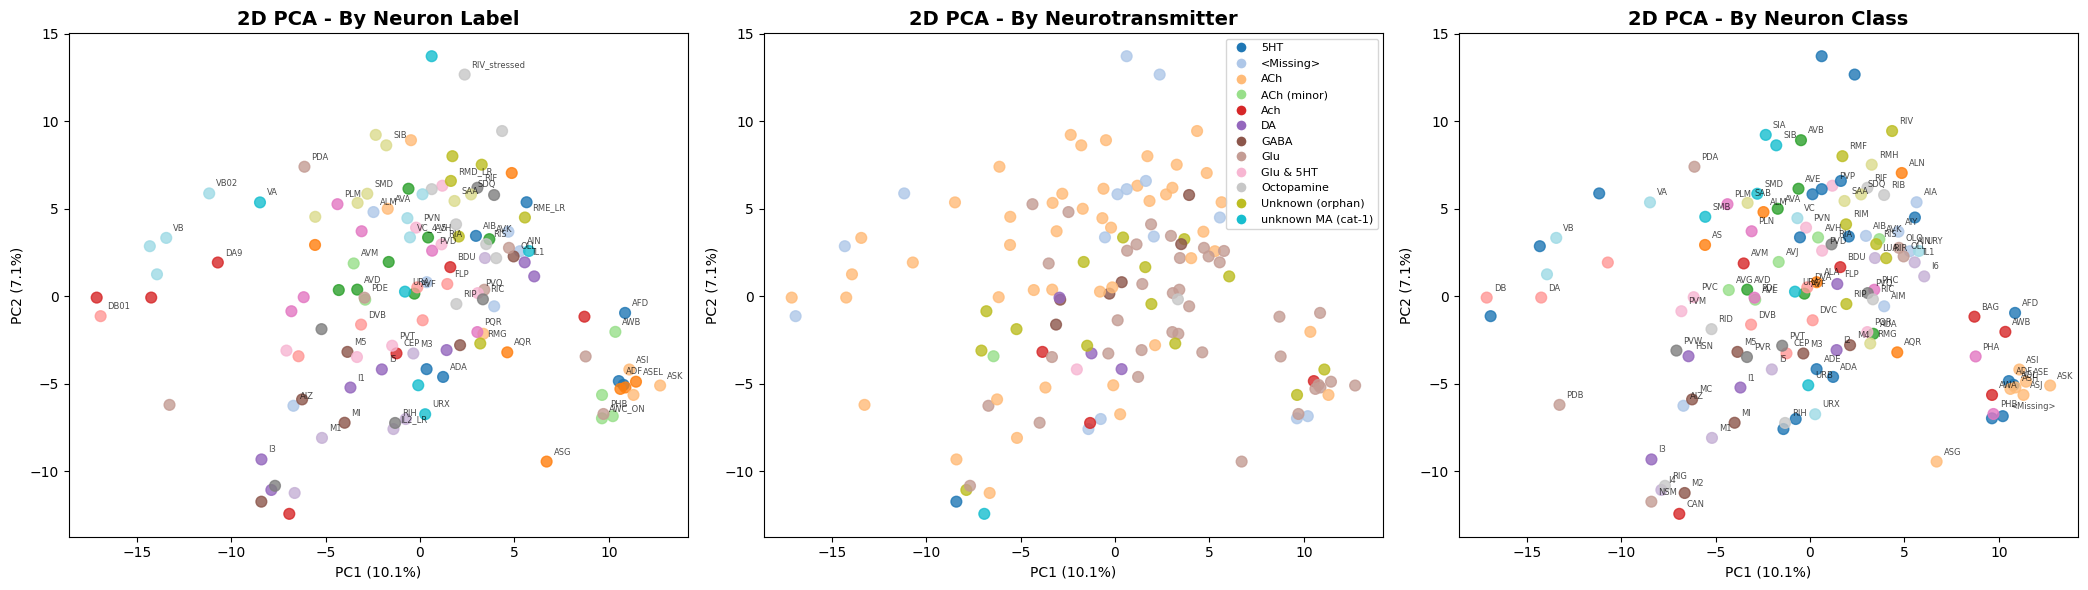

PCA visualization complete
X_pca shape: (130, 129)
Number of neurons: 130
Number of principal components: 129


In [6]:
# PCA Preprocessing for Dimensionality Reduction and Visualization
print("Applying PCA preprocessing to reduce dimensions and visualize data...")
print(f"Original data shape: {X_original.shape}")

# Maximum allowable PCA components is min(n_samples-1, n_features)
max_pca_components = min(N_neurons - 1, X_original.shape[1])
n_pca_components = max_pca_components  # Use maximum to preserve as much variance as possible

print(f"Using {n_pca_components} PCA components (max allowable: {max_pca_components})")

# Fit PCA
pca_preprocess = PCA(n_components=n_pca_components, random_state=41)
X_pca = pca_preprocess.fit_transform(X_original)

print(f"PCA preprocessed data shape: {X_pca.shape}")
print(f"Explained variance ratio (first 10 components): {pca_preprocess.explained_variance_ratio_[:10]}")
print(f"Total explained variance: {pca_preprocess.explained_variance_ratio_.sum():.4f}")

# Plot cumulative explained variance
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(range(1, min(50, len(pca_preprocess.explained_variance_ratio_)) + 1), 
         pca_preprocess.explained_variance_ratio_[:50], 'b-', linewidth=2)
plt.xlabel('Component')
plt.ylabel('Explained Variance Ratio')
plt.title('PCA Explained Variance (First 50 Components)')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(range(1, len(pca_preprocess.explained_variance_ratio_) + 1), 
         np.cumsum(pca_preprocess.explained_variance_ratio_), 'r-', linewidth=2)
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Cumulative Explained Variance')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Plot first two PCA components for visualization with metadata coloring
print("Plotting first two PCA components with metadata coloring...")

# Create figure with 3 subplots: original coloring, neurotransmitter, cell type
fig, axes = plt.subplots(1, 3, figsize=(21, 6))

# Prepare metadata color mappings
unique_nt = np.unique(neuron_neurotransmitters)
nt_to_color = {nt: i for i, nt in enumerate(unique_nt)}
unique_cls = np.unique(neuron_classes)
cls_to_color = {cls: i for i, cls in enumerate(unique_cls)}

# Prepare colormaps - use actual colors instead of indices
cmap = plt.cm.tab20
nt_color_values = [cmap(nt_to_color[nt] / len(unique_nt)) for nt in neuron_neurotransmitters]
cls_color_values = [cmap(cls_to_color[cls] / len(unique_cls)) for cls in neuron_classes]

# Plot 1: Original (by neuron index) with annotations for every other neuron
ax = axes[0]
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], 
                    c=range(len(neuron_labels)), cmap='tab20', s=60, alpha=0.8)
ax.set_title('2D PCA - By Neuron Label', fontsize=14, fontweight='bold')
ax.set_xlabel(f'PC1 ({pca_preprocess.explained_variance_ratio_[0]:.1%})')
ax.set_ylabel(f'PC2 ({pca_preprocess.explained_variance_ratio_[1]:.1%})')

# Add text annotations for every other neuron
for i in range(0, len(neuron_labels), 2):
    ax.annotate(neuron_labels[i],
                (X_pca[i, 0], X_pca[i, 1]),
                xytext=(5, 5), textcoords='offset points',
                fontsize=6, alpha=0.7)

# Plot 2: Colored by neurotransmitter
ax = axes[1]
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], 
                    c=nt_color_values, s=60, alpha=0.8)  # Use actual colors, not cmap
ax.set_title('2D PCA - By Neurotransmitter', fontsize=14, fontweight='bold')
ax.set_xlabel(f'PC1 ({pca_preprocess.explained_variance_ratio_[0]:.1%})')
ax.set_ylabel(f'PC2 ({pca_preprocess.explained_variance_ratio_[1]:.1%})')

# Add legend for neurotransmitters
handles = [plt.Line2D([0], [0], marker='o', color='w', 
                     markerfacecolor=cmap(nt_to_color[nt]/len(unique_nt)), 
                     markersize=8, label=nt) for nt in unique_nt]
ax.legend(handles=handles, loc='best', fontsize=8)

# Plot 3: Colored by neuron class with text annotations
ax = axes[2]
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], 
                    c=cls_color_values, s=60, alpha=0.8)
ax.set_title('2D PCA - By Neuron Class', fontsize=14, fontweight='bold')
ax.set_xlabel(f'PC1 ({pca_preprocess.explained_variance_ratio_[0]:.1%})')
ax.set_ylabel(f'PC2 ({pca_preprocess.explained_variance_ratio_[1]:.1%})')

# For each unique class, find one representative point and add text annotation
for cls in unique_cls:
    # Find indices where this class appears
    cls_indices = np.where(neuron_classes == cls)[0]
    if len(cls_indices) > 0:
        # Take the first occurrence as representative
        idx = cls_indices[0]
        # Add text annotation with small offset
        ax.annotate(cls, 
                   (X_pca[idx, 0], X_pca[idx, 1]),
                   xytext=(5, 5), textcoords='offset points',
                   fontsize=6, alpha=0.7)

plt.tight_layout()
plt.show()

print("PCA visualization complete")
print(f"X_pca shape: {X_pca.shape}")
print(f"Number of neurons: {N_neurons}")
print(f"Number of principal components: {X_pca.shape[1]}")


#### **OPTIONAL:** Choose a random subset of `input_dim` features to keep as the original data `X_original` to get embedded by the dataset class.


In [7]:
# Select a subset of features from X_original for embedding

# This gives us a manageable but still high-dimensional input space
input_dim = X_original.shape[1] - 1 #8192
print(f"Selecting {input_dim} random features from {X_original.shape[1]} total features")

# Randomly select input_dim features without replacement
selected_features = np.random.choice(X_original.shape[1], size=input_dim, replace=False)
selected_features.sort()  # Sort indices for consistency

# Create new X_original with only selected features
X_original = X_original[:, selected_features]
print(f"X_original shape: {X_original.shape}")
# NOTE: Do NOT standardize features (genes) with StandardScaler. It strips away the variance imformation.
print(f"Without standardization {X_original.mean(axis=0).shape} genes (first 5) \n\tmean: {X_original.mean(axis=0)[:5]}, \n\tstd: {X_original.std(axis=0)[:5]}")

print(f"\nData ready for embedding: {X_original.shape}")
print(f"This will be embedded to embedding_dim={CONFIG_TRANSCRIPTOMICS['embedding_dim']} by our dataset class")

Selecting 22468 random features from 22469 total features
X_original shape: (130, 22468)
Without standardization (22468,) genes (first 5) 
	mean: [2.87590796 1.01728045 0.8490579  1.07566784 1.96477043], 
	std: [0.92014032 0.41039817 0.42220107 0.57693753 0.81696442]

Data ready for embedding: (130, 22468)
This will be embedded to embedding_dim=512 by our dataset class


## Custom Transcriptome Dataset with Johnson-Lindenstrauss Random Projection

Since we have only one (N, D) embedding matrix from the original transcriptome data, we need to generate multiple training samples. Our innovation is to create synthetic but meaningful variations using Johnson-Lindenstrauss random Gaussian projections.

**Key insight**: Each random projection preserves pairwise distances between neurons with high probability (JL lemma guarantee), while creating novel projections. This allows generation of effectively unlimited training samples with theoretically grounded distance preservation.


In [8]:
# Calculate minimum dimension needed for JL lemma
n_samples = N_neurons  # We're preserving distances between neurons
epsilon = CONFIG_TRANSCRIPTOMICS['jl_epsilon']
min_dim = johnson_lindenstrauss_min_dim(n_samples=n_samples, eps=epsilon)
print(f"JL minimum dimension for n={n_samples}, eps={epsilon}: {min_dim}")
print(f"Original dimension: {X_original.shape[1]}")

# Create and fit GaussianRandomProjection
grp = GaussianRandomProjection(n_components=min_dim.item(), eps=epsilon)
X_projected = grp.fit_transform(X_original)

print(f"\nGaussian Random Projection output shape: {X_projected.shape}")
print(f"Projection matrix shape: {grp.components_.shape}")

JL minimum dimension for n=130, eps=0.3: 540
Original dimension: 22468

Gaussian Random Projection output shape: (130, 540)
Projection matrix shape: (540, 22468)


In [9]:
class TranscriptomeGaussianProjectionDataset(Dataset):
    """
    Dataset that generates synthetic transcriptome embeddings using sklearn GaussianRandomProjection.
    """
    
    def __init__(self, X_original, num_samples, embedding_dim, epsilon=0.1, seed=None, precompute=None):
        """
        Args:
            X_original: (N, D_original) numpy array of preprocessed transcriptome data
            num_samples: total number of augmented samples to generate
            embedding_dim: target dimension for random projection
            epsilon: JL epsilon parameter for distance preservation
            seed: base random seed for reproducibility
            precompute: if True, precompute all samples in __init__ for faster training
        """
        # Convert input to torch tensor if needed  
        self.X_original = torch.tensor(X_original, dtype=torch.float32) if isinstance(X_original, np.ndarray) else X_original # (N_neurons, input_dim)
        self.N_neurons, self.input_dim = X_original.shape
        self.num_samples = num_samples
        self.embedding_dim = embedding_dim
        self.epsilon = epsilon
        self.seed = seed
        self.precompute = num_samples <= 100 if precompute is None else precompute
        
        self.N, self.D_original = X_original.shape
        print(f"GaussianProjectionDataset: {self.N} neurons, {self.D_original} → {self.embedding_dim} dims, {self.num_samples} samples")
        
        if self.precompute:
            # Precompute all samples once in memory
            start_time = time.time()
            self.samples = []
            
            for idx in range(self.num_samples):
                sample = self.compute_sample(idx)
                self.samples.append(sample)
            
            end_time = time.time()
            duration = end_time - start_time
            print(f"Precomputed {len(self.samples)} samples in {duration:.2f} seconds ({duration/len(self.samples):.2f} seconds per sample)")
        else:
            # We will compute samples on the fly in __getitem__
            self.samples = None

    def compute_sample(self, idx):
        # Create a GaussianRandomProjection with unique seed for this sample
        if self.seed is not None:
            random_state = self.seed + idx
        else:
            random_state = idx
            
        projector = GaussianRandomProjection(
            n_components=self.embedding_dim,
            eps=self.epsilon,
            random_state=random_state
        )
        
        # Fit and transform the data
        X_projected = projector.fit_transform(self.X_original.numpy())  # (N_neurons, embedding_dim)

        # Convert back to a tensor and move to device
        X_tensor = torch.tensor(X_projected, dtype=torch.float32)
        
        return X_tensor

    def __len__(self):
        return self.num_samples
    
    def __getitem__(self, idx):
        if self.precompute:
            return self.samples[idx]
        else:
            return self.compute_sample(idx)


In [10]:
# Test the Gaussian Random Projection dataset
print("Testing the TranscriptomeGaussianProjectionDataset...")

# Set the embedding dimension to the minimum dimension needed for JL lemma
rp_embedding_dim = min_dim.item()
# Use this as our embedding dimension (update CONFIG_TRANSCRIPTOMICS if needed)
print(f"Updating CONFIG_TRANSCRIPTOMICS['embedding_dim'] from {CONFIG_TRANSCRIPTOMICS['embedding_dim']} to {rp_embedding_dim}")
CONFIG_TRANSCRIPTOMICS['embedding_dim'] = rp_embedding_dim

rp_dataset = TranscriptomeGaussianProjectionDataset(
    X_original=X_original,
    num_samples=10,  # Test with smaller number first
    embedding_dim=rp_embedding_dim,
    epsilon=CONFIG_TRANSCRIPTOMICS['jl_epsilon'],
    seed=42,
    precompute=True
)

# Test a few samples
rp_sample1 = rp_dataset[0]
print(f"\nSample shape: {rp_sample1.shape}, dtype: {rp_sample1.dtype}")
print(f"Sample mean (first 3 neurons): {rp_sample1.mean(dim=-1)[:3]}")
print(f"Sample std (first 3 neurons): {rp_sample1.std(dim=-1)[:3]}")

# Test that different samples are different from each other
rp_sample2 = rp_dataset[1]
diff = torch.norm(rp_sample1 - rp_sample2).item()
print(f"\nDifference between samples 1 and 2: {diff:.3f}")

rp_sampleN = rp_dataset[-1]
diff = torch.norm(rp_sample1 - rp_sampleN).item()
print(f"Difference between samples 1 and {len(rp_dataset)}: {diff:.3f}")

# Create data loader
rp_dataloader = DataLoader(rp_dataset, batch_size=CONFIG_TRANSCRIPTOMICS['batch_size'], shuffle=True)
rp_batch = next(iter(rp_dataloader))
print(f"\nBatch shape: {rp_batch.shape}")
print(f"Batch dtype: {rp_batch.dtype}")

Testing the TranscriptomeGaussianProjectionDataset...
Updating CONFIG_TRANSCRIPTOMICS['embedding_dim'] from 512 to 540
GaussianProjectionDataset: 130 neurons, 22468 → 540 dims, 10 samples
Precomputed 10 samples in 1.62 seconds (0.16 seconds per sample)

Sample shape: torch.Size([130, 540]), dtype: torch.float32
Sample mean (first 3 neurons): tensor([ 0.0039, -0.0103, -0.0224])
Sample std (first 3 neurons): tensor([1.3169, 1.2142, 1.3067])

Difference between samples 1 and 2: 483.665
Difference between samples 1 and 10: 478.113

Batch shape: torch.Size([10, 130, 540])
Batch dtype: torch.float32


### **Sanity Check:** Johnson-Lindenstrauss Distance Preservation

Let's verify that our random projection preserves pairwise distances between neurons (JL lemma guarantee). We'll compare pairwise distance correlations between different random projections.


In [11]:
# Sanity check: Test JL distance preservation between random projections
print("Performing sanity check on Johnson-Lindenstrauss distance preservation...")

# Get the original data and two of the random projections
rp_sample0 = rp_dataset.X_original.numpy() # Shape: (N, D_original)
rp_sample1 = rp_sample1.numpy()  # Shape: (N, D_embedding)
rp_sample2 = rp_sample2.numpy()  # Shape: (N, D_embedding)

# Compute pairwise distances for both projections
distances0 = pdist(rp_sample0)
distances1 = pdist(rp_sample1)
distances2 = pdist(rp_sample2)

# Calculate correlation between distance matrices
correlation_01 = np.corrcoef(distances0, distances1)[0, 1]
correlation_02 = np.corrcoef(distances0, distances2)[0, 1]
correlation_12 = np.corrcoef(distances1, distances2)[0, 1]

print(f"\nJL Distance Preservation Results:")
print(f"Original shape: {rp_sample0.shape}")
print(f"Sample 1 shape: {rp_sample1.shape}")
print(f"Sample 2 shape: {rp_sample2.shape}")
print(f"Correlation between pairwise distances (original vs sample1): {correlation_01:.4f}")
print(f"Correlation between pairwise distances (original vs sample2): {correlation_02:.4f}")
print(f"Correlation between pairwise distances (sample1 vs sample2): {correlation_12:.4f}")

# Get the mean of the 3 pairwise correlations
mean_correlation = (correlation_01 + correlation_02 + correlation_12) / 3

# Test JL lemma bounds
# JL lemma: (1-ε)||x-y||² ≤ ||Px-Py||² ≤ (1+ε)||x-y||²
# So correlation should be high (close to 1) for good distance preservation
expected_min_correlation = 1 - CONFIG_TRANSCRIPTOMICS['jl_epsilon']  # Rough approximation

print(f"Expected minimum correlation (1-ε): {expected_min_correlation:.3f}")
print(f"Estimated correlation (mean of 3) : {mean_correlation:.3f}")

if mean_correlation > expected_min_correlation:
    print("✓ PASS: JL distance preservation working correctly!")
else:
    print("⚠ WARNING: Distance preservation may not meet JL bounds")


Performing sanity check on Johnson-Lindenstrauss distance preservation...

JL Distance Preservation Results:
Original shape: (130, 22468)
Sample 1 shape: (130, 540)
Sample 2 shape: (130, 540)
Correlation between pairwise distances (original vs sample1): 0.9783
Correlation between pairwise distances (original vs sample2): 0.9813
Correlation between pairwise distances (sample1 vs sample2): 0.9587
Expected minimum correlation (1-ε): 0.700
Estimated correlation (mean of 3) : 0.973
✓ PASS: JL distance preservation working correctly!


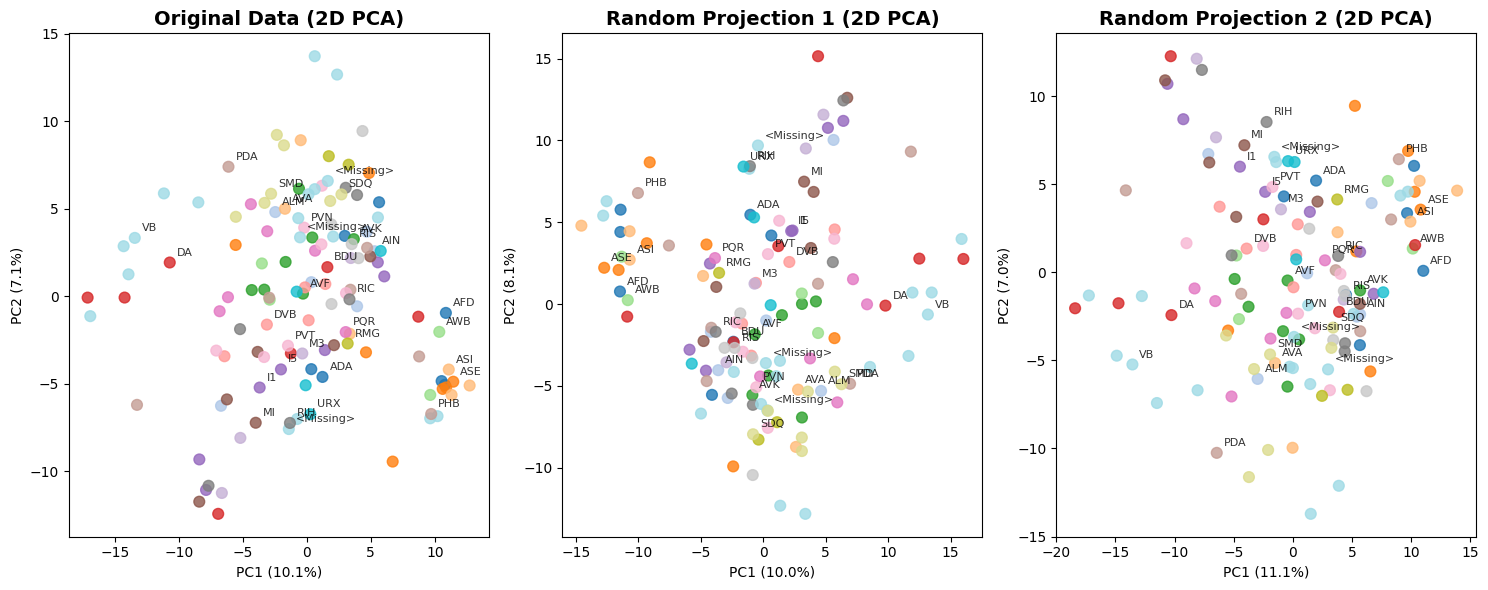

In [12]:
# Visualize with 2D PCA for both samples
pca1_2d = PCA(n_components=2, random_state=42)
pca2_2d = PCA(n_components=2, random_state=43)

# Fit PCA on first sample and transform both
rp_sample1_pca = pca1_2d.fit_transform(rp_sample1)
rp_sample2_pca = pca2_2d.fit_transform(rp_sample2)

# Create comparison plot
fig, (ax0, ax1, ax2) = plt.subplots(1, 3, figsize=(15, 6))

# Create a consistent color mapping for neurons
unique_colors = plt.cm.tab20(np.linspace(0, 1, len(neuron_classes)))
color_dict = dict(zip(neuron_classes, unique_colors))
colors = [color_dict[neuron] for neuron in neuron_classes]

# Plot original 
scatter0 = ax0.scatter(X_pca[:, 0], X_pca[:, 1], 
                      c=colors, s=60, alpha=0.8)
ax0.set_title('Original Data (2D PCA)', fontsize=14, fontweight='bold')
ax0.set_xlabel(f'PC1 ({pca_preprocess.explained_variance_ratio_[0]:.1%})')
ax0.set_ylabel(f'PC2 ({pca_preprocess.explained_variance_ratio_[1]:.1%})')

# Plot sample 1
scatter1 = ax1.scatter(rp_sample1_pca[:, 0], rp_sample1_pca[:, 1], 
                      c=colors, s=60, alpha=0.8)
ax1.set_title('Random Projection 1 (2D PCA)', fontsize=14, fontweight='bold')
ax1.set_xlabel(f'PC1 ({pca1_2d.explained_variance_ratio_[0]:.1%})')
ax1.set_ylabel(f'PC2 ({pca1_2d.explained_variance_ratio_[1]:.1%})')

# Plot sample 2
scatter2 = ax2.scatter(rp_sample2_pca[:, 0], rp_sample2_pca[:, 1], 
                      c=colors, s=60, alpha=0.8)
ax2.set_title('Random Projection 2 (2D PCA)', fontsize=14, fontweight='bold')
ax2.set_xlabel(f'PC1 ({pca2_2d.explained_variance_ratio_[0]:.1%})')
ax2.set_ylabel(f'PC2 ({pca2_2d.explained_variance_ratio_[1]:.1%})')

# Annotate a few points for reference
for i in range(0, len(neuron_classes), 4):  # Annotate every 4th neuron
    ax0.annotate(neuron_classes[i], (X_pca[i, 0], X_pca[i, 1]), 
                xytext=(5, 5), textcoords='offset points', fontsize=8, alpha=0.8)
    ax1.annotate(neuron_classes[i], (rp_sample1_pca[i, 0], rp_sample1_pca[i, 1]), 
                xytext=(5, 5), textcoords='offset points', fontsize=8, alpha=0.8)
    ax2.annotate(neuron_classes[i], (rp_sample2_pca[i, 0], rp_sample2_pca[i, 1]), 
                xytext=(5, 5), textcoords='offset points', fontsize=8, alpha=0.8)

plt.tight_layout()
plt.show()

### Custom Transcriptome Dataset with Random Feature Selection

A simpler and potentially more interpretable approach than projections is selecting subsets of genes. This is essentially doing feature subsampling, which is a common technique in machine learning. Each sample still represents a different "view" of the transcriptome but each view is a differen subset—rather than a projection—of the original features.

This approach has several advantages:
- **Interpretability:** We can see which genes are being used in each sample
- **Simplicity:** No need for JL projections - just random feature selection
- **Computational efficiency:** Much faster than random projections

The disadvantage of this approach is that it is no longer guaranteed to produce samples that preserve the pairwise metrics, such as distances between neurons, of the original transcriptome data.


In [13]:
class TranscriptomeFeatureSubsetDataset(Dataset):
    """
    Dataset that generates augmented embeddings by randomly selecting subsets of features (genes).
    Each sample uses a different random subset of embedding_dim features from the original data.
    
    This approach is simpler than random projections and more interpretable - we can see
    which genes are being used in each sample.
    """
    
    def __init__(self, X_original, num_samples, embedding_dim, seed=None, precompute=None):
        """
        Args:
            X_original: (N_neurons, input_dim) numpy array of preprocessed transcriptome data
            num_samples: total number of augmented samples to generate
            embedding_dim: number of features to randomly select for each sample
            seed: base random seed for reproducibility
            precompute: if True, precompute all samples in __init__ for faster training
        """
        # Convert input to tensor if needed
        self.X_original = torch.tensor(X_original, dtype=torch.float32) if isinstance(X_original, np.ndarray) else X_original
        self.N_neurons, self.input_dim = self.X_original.shape
        self.num_samples = num_samples
        self.embedding_dim = embedding_dim
        self.seed = seed
        self.precompute = num_samples <= 100 if precompute is None else precompute
        
        # Validate that we have enough features
        if self.embedding_dim > self.input_dim:
            raise ValueError(f"embedding_dim ({self.embedding_dim}) cannot be larger than number of features ({self.input_dim})")
        
        print(f"FeatureSubsetDataset: {self.N_neurons} neurons, {self.input_dim} features → {self.embedding_dim} features per sample, {self.num_samples} samples")
        
        if self.precompute:
            # Precompute all samples once in memory
            start_time = time.time()
            self.samples = []
            self.selected_features = []  # Store which features were selected for each sample
            
            for idx in range(self.num_samples):
                sample, selected_features = self.compute_sample(idx)
                self.samples.append(sample)
                self.selected_features.append(selected_features)
            
            end_time = time.time()
            duration = end_time - start_time
            print(f"Precomputed {len(self.samples)} samples in {duration:.2f} seconds ({duration/len(self.samples):.2f} seconds per sample)")
        else:
            # We will compute samples on the fly in __getitem__
            self.samples = None
            self.selected_features = None

    def compute_sample(self, idx):
        """
        Generate a sample by randomly selecting embedding_dim features.
        
        Returns:
            sample: torch tensor of shape (N_neurons, embedding_dim)
            selected_features: list of feature indices that were selected
        """
        # Set random seed for this sample
        if self.seed is not None:
            torch.manual_seed(self.seed + idx)
        else:
            torch.manual_seed(idx)
        
        # Randomly select embedding_dim features (without replacement)
        selected_features = torch.randperm(self.input_dim)[:self.embedding_dim]
        
        # Extract the selected genes for all neurons
        X_subset = self.X_original[:, selected_features]  # (N_neurons, embedding_dim)
        
        return X_subset, selected_features.tolist()

    def __len__(self):
        return self.num_samples
    
    def __getitem__(self, idx):
        if self.precompute:
            return self.samples[idx]
        else:
            sample, _ = self.compute_sample(idx)
            return sample
    
    def get_selected_features(self, idx):
        """
        Get the gene indices that were selected for a given sample.
        Only works if precompute=True.
        """
        if not self.precompute:
            raise ValueError("get_selected_features only works when precompute=True")
        return self.selected_features[idx]
    

In [14]:
# Test the Feature Subset Dataset
print("Testing the TranscriptomeFeatureSubsetDataset...")

# Choose whatever embedding_dim < input_dim  
fs_embedding_dim = 10384 # better results with larger value but speed is reduced

# Use this as our embedding dimension (update CONFIG_TRANSCRIPTOMICS if needed)
print(f"Updating CONFIG_TRANSCRIPTOMICS['embedding_dim'] from {CONFIG_TRANSCRIPTOMICS['embedding_dim']} to {fs_embedding_dim}")
CONFIG_TRANSCRIPTOMICS['embedding_dim'] = fs_embedding_dim

fs_dataset = TranscriptomeFeatureSubsetDataset(
    X_original=X_original,
    num_samples=10,  # Test with smaller number first
    embedding_dim=fs_embedding_dim,
    seed=42,
    precompute=True
)

# Test a few samples
fs_sample1 = fs_dataset[0]
print(f"\nSample shape: {fs_sample1.shape}, dtype: {fs_sample1.dtype}")
print(f"Sample mean (first 3 neurons): {fs_sample1.mean(dim=-1)[:3]}")
print(f"Sample std (first 3 neurons): {fs_sample1.std(dim=-1)[:3]}")

# Test that different samples are different
fs_sample2 = fs_dataset[1]
diff = torch.norm(fs_sample1 - fs_sample2).item()
print(f"\nDifference between samples 1 and 2: {diff:.3f}")

fs_sampleN = fs_dataset[-1]
diff = torch.norm(fs_sample1 - fs_sampleN).item()
print(f"Difference between samples 1 and {len(fs_dataset)}: {diff:.3f}")

# Create data loader
fs_dataloader = DataLoader(fs_dataset, batch_size=CONFIG_TRANSCRIPTOMICS['batch_size'], shuffle=True)
fs_batch = next(iter(fs_dataloader))
print(f"\nBatch shape: {fs_batch.shape}")
print(f"Batch dtype: {fs_batch.dtype}")


Testing the TranscriptomeFeatureSubsetDataset...
Updating CONFIG_TRANSCRIPTOMICS['embedding_dim'] from 540 to 10384
FeatureSubsetDataset: 130 neurons, 22468 features → 10384 features per sample, 10 samples
Precomputed 10 samples in 0.01 seconds (0.00 seconds per sample)

Sample shape: torch.Size([130, 10384]), dtype: torch.float32
Sample mean (first 3 neurons): tensor([0.0365, 0.0359, 0.0474])
Sample std (first 3 neurons): tensor([0.1996, 0.1758, 0.2034])

Difference between samples 1 and 2: 329.471
Difference between samples 1 and 10: 321.929

Batch shape: torch.Size([10, 130, 10384])
Batch dtype: torch.float32


We similarly sanity check our random feature subset samples but we do not expect that distances will be preserved if the `embedding_dim` we select is not sufficiently large to densely sample the space of original features.

In [15]:
# Sanity check: Distance not preserved with random feature subset selection
print("Performing sanity check on feature subset selection...")

# Get the original data and two of the random feature subsets
fs_sample0 = fs_dataset.X_original.numpy() # Shape: (N, D_original)
fs_sample1 = fs_sample1.numpy()  # Shape: (N, D_embedding)
fs_sample2 = fs_sample2.numpy()  # Shape: (N, D_embedding)

# Compute pairwise distances for both projections
distances0 = pdist(fs_sample0)
distances1 = pdist(fs_sample1)
distances2 = pdist(fs_sample2)

# Calculate correlation between distance matrices
correlation_01 = np.corrcoef(distances0, distances1)[0, 1]
correlation_02 = np.corrcoef(distances0, distances2)[0, 1]
correlation_12 = np.corrcoef(distances1, distances2)[0, 1]

print(f"\nJL Distance Preservation Results:")
print(f"Original shape: {fs_sample0.shape}")
print(f"Sample 1 shape: {fs_sample1.shape}")
print(f"Sample 2 shape: {fs_sample2.shape}")
print(f"Correlation between pairwise distances (original vs sample1): {correlation_01:.4f}")
print(f"Correlation between pairwise distances (original vs sample2): {correlation_02:.4f}")
print(f"Correlation between pairwise distances (sample1 vs sample2): {correlation_12:.4f}")

# Get the mean of the 3 pairwise correlations
mean_correlation = (correlation_01 + correlation_02 + correlation_12) / 3
print(f"Estimated correlation (mean of 3) : {mean_correlation:.3f}")

# Check which features were selected for each sample
selected_features_0 = fs_dataset.get_selected_features(0)
selected_features_1 = fs_dataset.get_selected_features(1)
print(f"\nSample 0 selected features (first 10): {selected_features_0[:10]}")
print(f"Sample 1 selected features (first 10): {selected_features_1[:10]}")
print(f"Overlap between samples 0 and 1: {len(set(selected_features_0) & set(selected_features_1))} features")

Performing sanity check on feature subset selection...

JL Distance Preservation Results:
Original shape: (130, 22468)
Sample 1 shape: (130, 10384)
Sample 2 shape: (130, 10384)
Correlation between pairwise distances (original vs sample1): 0.9292
Correlation between pairwise distances (original vs sample2): 0.9326
Correlation between pairwise distances (sample1 vs sample2): 0.8758
Estimated correlation (mean of 3) : 0.913

Sample 0 selected features (first 10): [18614, 8577, 1514, 21332, 8302, 8226, 15948, 462, 858, 5241]
Sample 1 selected features (first 10): [16864, 19948, 2323, 16665, 10457, 13980, 5180, 22384, 21325, 6347]
Overlap between samples 0 and 1: 4840 features


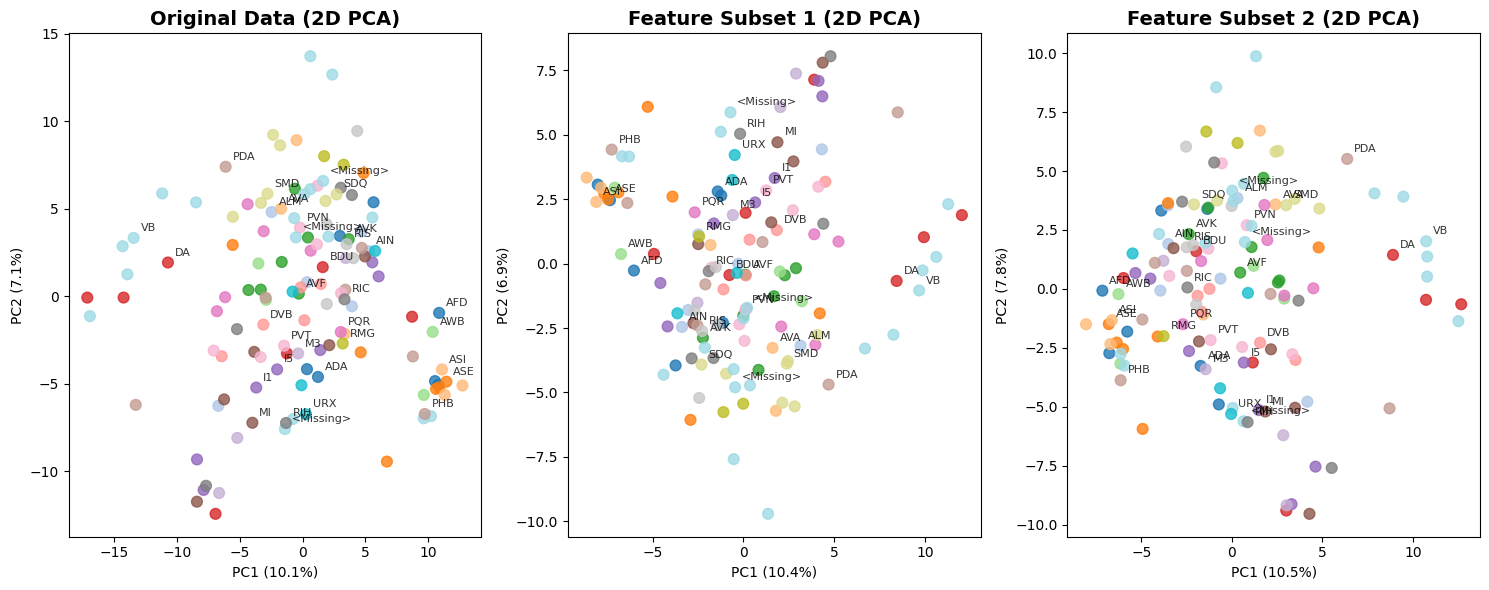

In [16]:
# Visualize with 2D PCA for feature subset samples
pca1_2d = PCA(n_components=2, random_state=42)
pca2_2d = PCA(n_components=2, random_state=43)

# Get two feature subset samples
fs_sample1 = fs_dataset[0]
fs_sample2 = fs_dataset[1]

# Fit PCA on first sample and transform both
fs_sample1_pca = pca1_2d.fit_transform(fs_sample1)
fs_sample2_pca = pca2_2d.fit_transform(fs_sample2)

# Create comparison plot
fig, (ax0, ax1, ax2) = plt.subplots(1, 3, figsize=(15, 6))

# Create a consistent color mapping for neurons
unique_colors = plt.cm.tab20(np.linspace(0, 1, len(neuron_classes)))
color_dict = dict(zip(neuron_classes, unique_colors))
colors = [color_dict[neuron] for neuron in neuron_classes]

# Plot original 
scatter0 = ax0.scatter(X_pca[:, 0], X_pca[:, 1], 
                      c=colors, s=60, alpha=0.8)
ax0.set_title('Original Data (2D PCA)', fontsize=14, fontweight='bold')
ax0.set_xlabel(f'PC1 ({pca_preprocess.explained_variance_ratio_[0]:.1%})')
ax0.set_ylabel(f'PC2 ({pca_preprocess.explained_variance_ratio_[1]:.1%})')

# Plot sample 1
scatter1 = ax1.scatter(fs_sample1_pca[:, 0], fs_sample1_pca[:, 1], 
                      c=colors, s=60, alpha=0.8)
ax1.set_title('Feature Subset 1 (2D PCA)', fontsize=14, fontweight='bold')
ax1.set_xlabel(f'PC1 ({pca1_2d.explained_variance_ratio_[0]:.1%})')
ax1.set_ylabel(f'PC2 ({pca1_2d.explained_variance_ratio_[1]:.1%})')

# Plot sample 2  
scatter2 = ax2.scatter(fs_sample2_pca[:, 0], fs_sample2_pca[:, 1], 
                      c=colors, s=60, alpha=0.8)
ax2.set_title('Feature Subset 2 (2D PCA)', fontsize=14, fontweight='bold')
ax2.set_xlabel(f'PC1 ({pca2_2d.explained_variance_ratio_[0]:.1%})')
ax2.set_ylabel(f'PC2 ({pca2_2d.explained_variance_ratio_[1]:.1%})')

# Annotate a few points for reference
for i in range(0, len(neuron_classes), 4):  # Annotate every 4th neuron
    ax0.annotate(neuron_classes[i], (X_pca[i, 0], X_pca[i, 1]), 
                xytext=(5, 5), textcoords='offset points', fontsize=8, alpha=0.8)
    ax1.annotate(neuron_classes[i], (fs_sample1_pca[i, 0], fs_sample1_pca[i, 1]), 
                xytext=(5, 5), textcoords='offset points', fontsize=8, alpha=0.8)
    ax2.annotate(neuron_classes[i], (fs_sample2_pca[i, 0], fs_sample2_pca[i, 1]), 
                xytext=(5, 5), textcoords='offset points', fontsize=8, alpha=0.8)

plt.tight_layout()
plt.show()

In [17]:
# Compare Feature Subset vs Random Projection approaches
print("="*80)
print("COMPARING FEATURE SUBSET vs RANDOM PROJECTION APPROACHES")
print("="*80)

# Create both datasets with same common parameters
n_samples = 50
embedding_dim = 512
print(f"Creating datasets with {n_samples} samples, {embedding_dim} dimensions...")

# Random Projection Dataset
rp_dataset = TranscriptomeGaussianProjectionDataset(
    X_original=X_original,
    num_samples=n_samples,
    embedding_dim=embedding_dim,
    epsilon=CONFIG_TRANSCRIPTOMICS['jl_epsilon'],
    seed=42,
    precompute=True
)

# Feature Subset Dataset
fs_dataset = TranscriptomeFeatureSubsetDataset(
    X_original=X_original,
    num_samples=n_samples,
    embedding_dim=embedding_dim,
    seed=42,
    precompute=True
)

print(f"\nDataset comparison:")
print(f"  Random Projection: {rp_dataset.__class__.__name__}")
print(f"  Feature Subset: {fs_dataset.__class__.__name__}")

# Compare sample properties
rp_sample = rp_dataset[0]
fs_sample = fs_dataset[0]

print(f"\nSample properties:")
print(f"  Random Projection - Shape: {rp_sample.shape}, Mean: {rp_sample.mean():.4f}, Std: {rp_sample.std():.4f}")
print(f"  Feature Subset - Shape: {fs_sample.shape}, Mean: {fs_sample.mean():.4f}, Std: {fs_sample.std():.4f}")

# Compare pairwise distances preservation
print(f"\nDistance preservation analysis:")

# Get a few samples from each dataset
rp_samples = [rp_dataset[i].numpy() for i in range(5)]
fs_samples = [fs_dataset[i].numpy() for i in range(5)]

# Calculate pairwise distance correlations
rp_correlations = []
fs_correlations = []

for i in range(5):
    # Random projection correlations
    rp_dist = pdist(rp_samples[i])
    rp_corr = np.corrcoef(pdist(X_original), rp_dist)[0, 1]
    rp_correlations.append(rp_corr)
    
    # Feature subset correlations
    fs_dist = pdist(fs_samples[i])
    fs_corr = np.corrcoef(pdist(X_original), fs_dist)[0, 1]
    fs_correlations.append(fs_corr)

print(f"  Random Projection distance correlations: {np.mean(rp_correlations):.4f} ± {np.std(rp_correlations):.4f}")
print(f"  Feature Subset distance correlations: {np.mean(fs_correlations):.4f} ± {np.std(fs_correlations):.4f}")


COMPARING FEATURE SUBSET vs RANDOM PROJECTION APPROACHES
Creating datasets with 50 samples, 512 dimensions...
GaussianProjectionDataset: 130 neurons, 22468 → 512 dims, 50 samples
Precomputed 50 samples in 7.28 seconds (0.15 seconds per sample)
FeatureSubsetDataset: 130 neurons, 22468 features → 512 features per sample, 50 samples
Precomputed 50 samples in 0.02 seconds (0.00 seconds per sample)

Dataset comparison:
  Random Projection: TranscriptomeGaussianProjectionDataset
  Feature Subset: TranscriptomeFeatureSubsetDataset

Sample properties:
  Random Projection - Shape: torch.Size([130, 512]), Mean: -0.0692, Std: 1.3290
  Feature Subset - Shape: torch.Size([130, 512]), Mean: 0.0369, Std: 0.1376

Distance preservation analysis:
  Random Projection distance correlations: 0.9781 ± 0.0017
  Feature Subset distance correlations: 0.4758 ± 0.0866


In [18]:
# Configuration for choosing between dataset approaches
print("="*80)
print("DATASET APPROACH CONFIGURATION")
print("="*80)

batch_size = CONFIG_TRANSCRIPTOMICS['batch_size']
dataset_type = CONFIG_TRANSCRIPTOMICS['dataset_type']
if dataset_type == 'random_projection':
    embedding_dim = rp_embedding_dim
else:
    embedding_dim = fs_embedding_dim
CONFIG_TRANSCRIPTOMICS['embedding_dim'] = embedding_dim

print(f"Current dataset type: {dataset_type}")
print(f"Embedding dimension: {embedding_dim}, Batch size: {batch_size}")

def create_transcriptome_dataset(X_original, num_samples, embedding_dim, config=dict(), seed=None, precompute=None):
    """
    Factory function to create the appropriate transcriptome dataset based on config.
    
    Args:
        X_original: (N_neurons, N_genes) numpy array
        num_samples: number of samples to generate
        embedding_dim: target embedding dimension
        config: configuration dictionary
        seed: random seed
        precompute: whether to precompute samples
    
    Returns:
        Dataset object (either TranscriptomeGaussianProjectionDataset or TranscriptomeFeatureSubsetDataset)
    """
    dataset_type = config.get('dataset_type', 'feature_subset')
    if dataset_type == 'random_projection':
        return TranscriptomeGaussianProjectionDataset(
            X_original=X_original,
            num_samples=num_samples,
            embedding_dim=embedding_dim,
            epsilon=config.get('jl_epsilon', 0.5),
            seed=seed,
            precompute=precompute
        )
    elif dataset_type == 'feature_subset':
        return TranscriptomeFeatureSubsetDataset(
            X_original=X_original,
            num_samples=num_samples,
            embedding_dim=embedding_dim,
            seed=seed,
            precompute=precompute
        )
    else:
        raise ValueError(f"Unknown dataset_type: {dataset_type}. Must be 'random_projection' or 'feature_subset'")

# Test the factory function
print(f"\nTesting dataset factory function...")
test_dataset = create_transcriptome_dataset(
    X_original=X_original,
    num_samples=batch_size,
    embedding_dim=embedding_dim,
    config=CONFIG_TRANSCRIPTOMICS,
    seed=42,
    precompute=True
)
test_dataloader = DataLoader(test_dataset, batch_size=CONFIG_TRANSCRIPTOMICS['batch_size'], shuffle=True)
test_batch = next(iter(test_dataloader)).to(device)

print(f"\nCreated dataset: {test_dataset.__class__.__name__} ({len(test_dataset)} samples)")
print(f"Dataloader length: {len(test_dataloader)}")
print(f"Dataset sample shape, dtype: {test_dataset[0].shape}, {test_dataset[0].dtype}")
print(f"Batch shape, dtype: {test_batch.shape}, {test_batch.dtype}")

DATASET APPROACH CONFIGURATION
Current dataset type: random_projection
Embedding dimension: 540, Batch size: 16

Testing dataset factory function...
GaussianProjectionDataset: 130 neurons, 22468 → 540 dims, 16 samples
Precomputed 16 samples in 2.48 seconds (0.15 seconds per sample)

Created dataset: TranscriptomeGaussianProjectionDataset (16 samples)
Dataloader length: 1
Dataset sample shape, dtype: torch.Size([130, 540]), torch.float32
Batch shape, dtype: torch.Size([16, 130, 540]), torch.float32


## Attention Model Architecture with Random Dropout Masking

We implement the `SingleHeadSelfAttention` module that learns to reconstruct each neuron's embedding using only the embeddings of other neurons. The key innovations are:
1. Diagonal masking that prevents self-attention
2. Random dropout masking during training that forces robust attention patterns

**Architecture**:
- Input: (batch, N, D) tensor of neuron embeddings
- Output: reconstructed embeddings and attention weights
- Diagonal mask: A[i,i] = 0 (prevent self-attention)
- Random dropout mask: During training, randomly mask 1 additional neuron per row to prevent overfitting


In [19]:
class SingleHeadSelfAttention(nn.Module):
    def __init__(self, d_model, n_hidden, use_attention_scores=False, verbose_timing=False):
        """
        A single head of self-attention that projects input tokens to queries, keys and values.
        The value projection implements an identity function (i.e. the values `V` will equal the input `x`) 
        so no output projection needed.
        
        Args:
            d_model: the dimension of the input tokens (D)
            n_hidden: the hidden dimension for Q/K projections
            use_attention_scores: if True, use raw attention scores instead of softmax weights
            verbose_timing: if True, print timing information for each step
        """
        super().__init__()
        # Q, K, and V projections
        self.W_Q = nn.Linear(d_model, n_hidden, bias=False)  # Query projection
        self.W_K = nn.Linear(d_model, n_hidden, bias=False)  # Key projection
        self.W_V = nn.Identity()  # Value projection; Using Identity means values = inputs
        # NOTE: If we were to use multiple heads: 
        # W_Q and W_K would be torch.nn.Linear(d_model, n_hidden*num_heads, bias=False)
        # W_V would be num_heads Identity matrices vertically stacked 
        #     i.e. matrix shape (output_dim, input_dim) = (num_heads*d_model, d_model)
        #     id = torch.eye(d_model); param = torch.nn.Parameter( torch.concat( num_heads * (id, ) ), requires_grad=False )
        #     W_V = torch.nn.Linear(d_model, num_heads*d_model, bias=False); W_V.weight = param; 
        #     Just to make sure: [ param.requires_grad_(False) for param in W_V.parameters() ]
        self.d_model = d_model
        self.n_hidden = n_hidden
        self.use_attention_scores = use_attention_scores
        self.verbose_timing = verbose_timing

    def forward(self, x, attn_mask=None, attn_dropout=0.0):
        """
        NOTE: Tokens in are the same shape as the tokens out (batch, n_neurons, d_model).
        Args:
            x: input token tensor (i.e. embeddings) of shape (batch, n_neurons, d_model)
            attn_mask: optional mask tensor of shape (batch, n_neurons, n_neurons); defaults to diagonal 'self' mask.
            attn_dropout: float between 0 and 1, fraction of neurons to randomly mask per row

        Returns:
            dict containing:
                - output: reconstructed embeddings of shape (batch, n_neurons, d_model)
                - attn_weights: attention weights of shape (batch, n_neurons, n_neurons)
                - attn_scores: attention scores of shape (batch, n_neurons, n_neurons)
                - attn_mask: attention mask of shape (batch, n_neurons, n_neurons)
        """
        start_time = time.time()
        batch_size, n_neurons, d_model = x.shape
        device = x.device

        # Compute Q, K, V projections
        Q = self.W_Q(x)  # (batch, n_neurons, n_hidden)
        K = self.W_K(x)  # (batch, n_neurons, n_hidden)
        V = self.W_V(x)  # (batch, n_neurons, d_model)
        # # NOTE: If we were to use multiple heads:
        # Q = self.W_Q(x).view((batch, n_neurons, -1, self.n_hidden)).transpose(1, 2) # (batch, num_heads, n_neurons, n_hidden)
        # K = self.W_K(x).view((batch, n_neurons, -1, self.n_hidden)).transpose(1, 2) # (batch, num_heads, n_neurons, n_hidden)
        # V = self.W_V(x).view((batch, n_neurons, -1, self.d_model)).transpose(1, 2) # (batch, num_heads, n_neurons, d_model)
        print(f"QK/V projections done in {time.time() - start_time:.3f}s") if self.verbose_timing else None

        # Create base diagonal mask (1 everywhere except diagonal)
        mask_time = time.time()
        if attn_mask is None:
            attn_mask = (1 - torch.eye(n_neurons, device=device)).unsqueeze(0).expand(batch_size, -1, -1)
        
        # Apply attention dropout if specified
        if attn_dropout > 0:
            # Calculate number of neurons to mask per row
            n_mask = int(attn_dropout * n_neurons)
            if n_mask > 0:
                # Clone mask to avoid modifying the original
                attn_mask = attn_mask.clone()
                
                # Generate random permutations for all batch x neurons at once
                # Shape: (batch_size, n_neurons, n_neurons)
                random_perms = torch.stack([torch.randperm(n_neurons, device=device) 
                                         for _ in range(batch_size * n_neurons)]).view(batch_size, n_neurons, n_neurons)
                
                # Create mask from first n_mask indices of each permutation
                dropout_mask = torch.zeros((batch_size, n_neurons, n_neurons), device=device)
                dropout_mask.scatter_(2, random_perms[:, :, :n_mask], 1)
                
                # Apply dropout mask to attention mask
                attn_mask = attn_mask * (1 - dropout_mask)
        
        print(f"Attention masking done in {time.time() - mask_time:.3f}s") if self.verbose_timing else None

        # Compute attention
        attn_time = time.time()
        # Compute scaled dot-product attention scores
        scores = torch.bmm(Q, K.transpose(1, 2)) / (self.n_hidden**0.5)
        
        # Apply mask by setting masked positions to -inf
        inf_masked_scores = scores.masked_fill(attn_mask == 0, float("-inf"))

        # Compute masked attention weights
        attn_weights = torch.softmax(inf_masked_scores, dim=-1)

        # We want masked scores but with 0s instead of -infs for visualization
        attn_scores = scores.masked_fill(attn_mask == 0, 0.0)
        print(f"Attention computation done in {time.time() - attn_time:.3f}s") if self.verbose_timing else None

        # Apply attention to values
        recon_time = time.time()
        if self.use_attention_scores:
            reconstructed = torch.bmm(attn_scores, V)
        else:
            reconstructed = torch.bmm(attn_weights, V)
        print(f"Reconstruction done in {time.time() - recon_time:.3f}s") if self.verbose_timing else None
        print(f"Total forward pass time: {time.time() - start_time:.3f}s") if self.verbose_timing else None

        return {
            'output': reconstructed,
            'attn_weights': attn_weights,
            'attn_scores': attn_scores,
            'attn_mask': attn_mask
        }


In [20]:
# Test the attention model
print("Testing SingleHeadSelfAttention model...")
print(f"Using device: {device}")

# Create model for transcriptomics
model_transcriptomics = SingleHeadSelfAttention(
    d_model=CONFIG_TRANSCRIPTOMICS['embedding_dim'],
    n_hidden=CONFIG_TRANSCRIPTOMICS['hidden_dim'],
    use_attention_scores=CONFIG_TRANSCRIPTOMICS['use_attention_scores']
).to(device)

print(f"SingleHeadSelfAttention created with {sum(p.numel() for p in model_transcriptomics.parameters()):,} parameters")


Testing SingleHeadSelfAttention model...
Using device: mps
SingleHeadSelfAttention created with 276,480 parameters



Masking without Dropout
	Time taken: 0.071s
	Attention shape: torch.Size([16, 130, 130])
	Reconstructed shape: torch.Size([16, 130, 540])
	Reconstruction error: 19.766


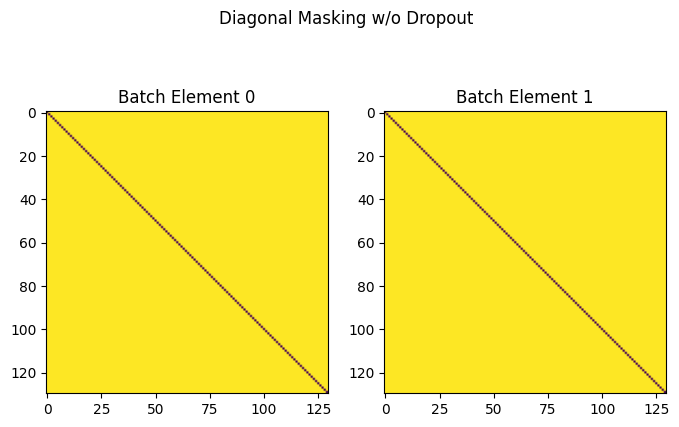


Masking with Dropout
	Time taken: 0.337s
	Attention shape: torch.Size([16, 130, 130])
	Reconstructed shape: torch.Size([16, 130, 540])
	Reconstruction error: 19.766


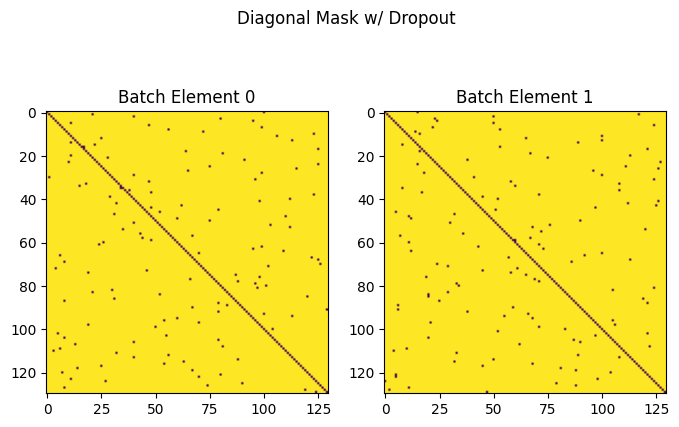

In [21]:
# Test with just the diagonal mask
model_transcriptomics.eval()
with torch.no_grad():
    start_time = time.time()
    output_regular = model_transcriptomics(test_batch, attn_dropout=0.0)
    reconstruction_error_regular = torch.norm(test_batch - output_regular['output'], dim=-1).mean()

print(f"\nMasking without Dropout")
print(f"\tTime taken: {time.time() - start_time:.3f}s")
print(f"\tAttention shape: {output_regular['attn_weights'].shape}")
print(f"\tReconstructed shape: {output_regular['output'].shape}")
print(f"\tReconstruction error: {reconstruction_error_regular:.3f}")

# Plot the attention mask of two batch elements to show that the diagonal masking and that it is the same for each element
fig, axes = plt.subplots(1, 2, figsize=(8, 5))
axes[0].imshow(output_regular['attn_mask'][0].cpu())
axes[0].set_title('Batch Element 0')
axes[1].imshow(output_regular['attn_mask'][1].cpu())
axes[1].set_title('Batch Element 1')
plt.suptitle('Diagonal Masking w/o Dropout')
plt.show()

# Test with additional dropout masking
model_transcriptomics.train()
with torch.no_grad():
    start_time = time.time()
    output_dropout = model_transcriptomics(test_batch, attn_dropout=0.01)
    reconstruction_error_dropout = torch.norm(test_batch - output_dropout['output'], dim=-1).mean()

print(f"\nMasking with Dropout")
print(f"\tTime taken: {time.time() - start_time:.3f}s")
print(f"\tAttention shape: {output_dropout['attn_weights'].shape}")
print(f"\tReconstructed shape: {output_dropout['output'].shape}")
print(f"\tReconstruction error: {reconstruction_error_dropout:.3f}")

# Plot the attention mask of two batch elements to show that the dropout and that it is different for each element
fig, axes = plt.subplots(1, 2, figsize=(8, 5))
axes[0].imshow(output_dropout['attn_mask'][0].cpu())
axes[0].set_title('Batch Element 0')
axes[1].imshow(output_dropout['attn_mask'][1].cpu())
axes[1].set_title('Batch Element 1')
plt.suptitle('Diagonal Mask w/ Dropout')
plt.show()


## Deep Transformer Decoder Architecture

### Overview
We implement a deep Transformer decoder architecture with stacked decoder blocks, each containing masked self-attention, feed-forward MLP, and layer normalization with residual connections using the **pre-norm** style.

### Decoder Block Architecture (Pre-Norm Style)
Each decoder block follows this architecture:
1. **LayerNorm → Masked Self-Attention → Residual**
2. **LayerNorm → MLP (Feed-Forward) → Residual**

### Why Pre-Norm?
- **Training Stability**: Pre-norm architectures are more stable during training
- **Better Gradient Flow**: Layer normalization before each sub-layer improves gradient flow
- **Modern Standard**: Most recent Transformer implementations use pre-norm

### Components
- **Masked Self-Attention**: Uses our `SingleHeadSelfAttention` with diagonal masking
- **MLP**: 2-layer feed-forward network with GELU activation and expansion factor (default 4x)
- **Layer Normalization**: Applied before each sub-layer (pre-norm style)
- **Residual Connections**: Skip connections around each sub-layer

### Usage
- **Shallow Model** (`n_layers=1`): Equivalent to `SingleHeadSelfAttention` + MLP
- **Deep Model** (`n_layers>1`): Stacked decoder blocks for more complex representations

### Transformer Decoder
![Decoder Architecture](figures/transformer_decoder.png)



In [22]:
class DecoderBlock(nn.Module):
    def __init__(self, d_model, n_hidden, mlp_expansion=4, dropout=0.1, 
                 use_attention_scores=False, verbose_timing=False):
        """
        A single Transformer decoder block with pre-norm architecture.
        
        Architecture:
        1. LayerNorm → Masked Self-Attention → Residual
        2. LayerNorm → MLP (Feed-Forward) → Residual
        
        Args:
            d_model: dimension of input/output embeddings
            n_hidden: hidden dimension for Q/K projections in attention
            mlp_expansion: expansion factor for MLP hidden layer (default 4x)
            dropout: dropout rate for MLP
            use_attention_scores: if True, use raw scores instead of softmax weights
            verbose_timing: if True, print timing information
        """
        super().__init__()
        
        # Layer normalization
        self.input_layernorm = nn.LayerNorm(d_model)
        self.post_attention_layernorm = nn.LayerNorm(d_model)
        
        # Masked self-attention
        self.self_attn = SingleHeadSelfAttention(
            d_model=d_model,
            n_hidden=n_hidden,
            use_attention_scores=use_attention_scores,
            verbose_timing=verbose_timing
        )
        
        # Feed-forward MLP (2-layer with expansion)
        mlp_hidden = d_model * mlp_expansion
        self.mlp = nn.Sequential(
            nn.Linear(d_model, mlp_hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(mlp_hidden, d_model),
            nn.Dropout(dropout)
        )
        
        self.dropout = dropout
    
    def forward(self, x, attn_mask=None, attn_dropout=0.0):
        """
        Forward pass with a pre-norm architecture.
        
        Args:
            x: input tensor (batch, n_neurons, d_model)
            attn_mask: optional attention mask (batch, n_neurons, n_neurons)
            attn_dropout: dropout rate for attention masking
        
        Returns:
            dict with keys:
                - 'output': output tensor (batch, n_neurons, d_model)
                - 'attn_weights': attention weights (batch, n_neurons, n_neurons)
                - 'attn_scores': attention scores (batch, n_neurons, n_neurons)
                - 'attn_mask': attention mask (batch, n_neurons, n_neurons)
        """
        # LayerNorm → Attention → Residual
        residual = x
        x_norm = self.input_layernorm(x) # Pre-attention layer norm
        attn_output = self.self_attn(x, attn_mask=attn_mask, attn_dropout=attn_dropout)
        x = residual + attn_output['output']
        
        # LayerNorm → MLP → Residual
        residual = x
        x_norm = self.post_attention_layernorm(x) # Post-attention / pre-MLP layer norm
        mlp_output = self.mlp(x_norm)
        x = residual + mlp_output
        
        return {
            'output': x,
            'attn_weights': attn_output['attn_weights'],
            'attn_scores': attn_output['attn_scores'],
            'attn_mask': attn_output['attn_mask']
        }


In [23]:
# Test DecoderBlock
print("\n1. Testing DecoderBlock...")
decoder_block = DecoderBlock(
    d_model=512,
    n_hidden=256,
    mlp_expansion=4,
    dropout=0.1,
    use_attention_scores=False,
    verbose_timing=False
).to(device)

# Test with sample input
test_input = torch.randn(4, 130, 512).to(device)  # batch=4, n_neurons=130, d_model=512
print(f"Input shape: {test_input.shape}")

# Forward pass
decoder_output = decoder_block(test_input)
print(f"DecoderBlock output shape: {decoder_output['output'].shape}")
print(f"DecoderBlock attention weights shape: {decoder_output['attn_weights'].shape}")
print(f"DecoderBlock parameters: {sum(p.numel() for p in decoder_block.parameters()):,}")



1. Testing DecoderBlock...
Input shape: torch.Size([4, 130, 512])
DecoderBlock output shape: torch.Size([4, 130, 512])
DecoderBlock attention weights shape: torch.Size([4, 130, 130])
DecoderBlock parameters: 2,363,904


In [24]:
class DeepConnectomeTransformer(nn.Module):
    def __init__(self, d_model, n_hidden, n_layers=1, mlp_expansion=4, 
                 dropout=0.1, use_attention_scores=False, verbose_timing=False):
        """
        Deep Transformer with stacked decoder blocks for connectome learning.
        
        Args:
            d_model: dimension of input/output embeddings
            n_hidden: hidden dimension for Q/K projections in attention
            n_layers: number of decoder blocks to stack
            mlp_expansion: expansion factor for MLP hidden layers
            dropout: dropout rate for MLP layers
            use_attention_scores: if True, use raw scores instead of softmax weights
            verbose_timing: if True, print timing information
        """
        super().__init__()
        
        self.n_layers = n_layers
        self.d_model = d_model
        
        # Stack of decoder blocks
        self.layers = nn.ModuleList([
            DecoderBlock(
                d_model=d_model,
                n_hidden=n_hidden,
                mlp_expansion=mlp_expansion,
                dropout=dropout,
                use_attention_scores=use_attention_scores,
                verbose_timing=verbose_timing
            )
            for _ in range(n_layers)
        ])
    
    def forward(self, x, attn_mask=None, attn_dropout=0.0, return_all_layers=False):
        """
        Forward pass through all decoder blocks.
        
        Args:
            x: input tensor (batch, n_neurons, d_model)
            attn_mask: optional attention mask (batch, n_neurons, n_neurons)
            attn_dropout: dropout rate for attention masking (applied at each layer)
            return_all_layers: if True, return attention info from all layers
        
        Returns:
            dict with keys:
                - 'output': final output tensor (batch, n_neurons, d_model)
                - 'attn_weights': attention weights from last layer (or list if return_all_layers=True)
                - 'attn_scores': attention scores from last layer (or list if return_all_layers=True)
                - 'attn_mask': attention mask from last layer (or list if return_all_layers=True)
        """
        all_attn_weights = []
        all_attn_scores = []
        all_attn_masks = []
        
        # Pass through each decoder block
        for layer in self.layers:
            layer_output = layer(x, attn_mask=attn_mask, attn_dropout=attn_dropout)
            x = layer_output['output']
            
            if return_all_layers:
                all_attn_weights.append(layer_output['attn_weights'])
                all_attn_scores.append(layer_output['attn_scores'])
                all_attn_masks.append(layer_output['attn_mask'])
        
        if return_all_layers:
            return {
                'output': x,
                'attn_weights': all_attn_weights,
                'attn_scores': all_attn_scores,
                'attn_mask': all_attn_masks
            }
        else:
            # Return only the last layer's attention info
            return {
                'output': x,
                'attn_weights': layer_output['attn_weights'],
                'attn_scores': layer_output['attn_scores'],
                'attn_mask': layer_output['attn_mask']
            }


In [25]:
# Test DeepConnectomeTransformer
print("\n2. Testing DeepConnectomeTransformer...")
deep_transformer = DeepConnectomeTransformer(
    d_model=512,
    n_hidden=256,
    n_layers=3,  # Test with 3 layers
    mlp_expansion=4,
    dropout=0.1,
    use_attention_scores=False,
    verbose_timing=False
).to(device)

# Forward pass
transformer_output = deep_transformer(test_input, attn_dropout=0.01)
print(f"DeepConnectomeTransformer output shape: {transformer_output['output'].shape}")
print(f"DeepConnectomeTransformer attention weights shape: {transformer_output['attn_weights'].shape}")
print(f"DeepConnectomeTransformer parameters: {sum(p.numel() for p in deep_transformer.parameters()):,}")

# Test return_all_layers
print("\n3. Testing return_all_layers=True...")
transformer_output_all = deep_transformer(test_input, attn_dropout=0.01, return_all_layers=True)
print(f"Number of layers: {len(transformer_output_all['attn_weights'])}")
print(f"Attention weights from each layer: {[w.shape for w in transformer_output_all['attn_weights']]}")

print("\n✓ All tests passed! Deep Transformer classes are working correctly.")



2. Testing DeepConnectomeTransformer...
DeepConnectomeTransformer output shape: torch.Size([4, 130, 512])
DeepConnectomeTransformer attention weights shape: torch.Size([4, 130, 130])
DeepConnectomeTransformer parameters: 7,091,712

3. Testing return_all_layers=True...
Number of layers: 3
Attention weights from each layer: [torch.Size([4, 130, 130]), torch.Size([4, 130, 130]), torch.Size([4, 130, 130])]

✓ All tests passed! Deep Transformer classes are working correctly.


In [ ]:
# Example: How to use DeepConnectomeTransformer instead of SingleHeadSelfAttention
print("Example: Using DeepConnectomeTransformer for transcriptomics...")

# Use DeepConnectomeTransformer (n_layers=1 is equivalent to SingleHeadSelfAttention + MLP)
model_transcriptomics = DeepConnectomeTransformer(
    d_model=CONFIG_TRANSCRIPTOMICS['embedding_dim'],
    n_hidden=CONFIG_TRANSCRIPTOMICS['hidden_dim'],
    n_layers=CONFIG_TRANSCRIPTOMICS['n_layers'], 
    mlp_expansion=CONFIG_TRANSCRIPTOMICS['mlp_expansion'],
    dropout=CONFIG_TRANSCRIPTOMICS['dropout'],
    use_attention_scores=CONFIG_TRANSCRIPTOMICS['use_attention_scores']
).to(device)

print(f"DeepConnectomeTransformer created with {sum(p.numel() for p in model_transcriptomics.parameters()):,} parameters")
print(f"Architecture: {CONFIG_TRANSCRIPTOMICS['n_layers']} decoder blocks")
print(f"MLP expansion: {CONFIG_TRANSCRIPTOMICS['mlp_expansion']}x")
print(f"Dropout: {CONFIG_TRANSCRIPTOMICS['dropout']}")

# Test forward pass
output = model_transcriptomics(test_batch)
print(f"Output shape: {output['output'].shape}")
print(f"Attention weights shape: {output['attn_weights'].shape}")


Example: Using DeepConnectomeTransformer for transcriptomics...
DeepConnectomeTransformer created with 7,842,420 parameters
Architecture: 3 decoder blocks
MLP expansion: 4x
Dropout: 0.1
Output shape: torch.Size([16, 130, 540])
Attention weights shape: torch.Size([16, 130, 130])

✓ DeepConnectomeTransformer is ready to use!
Replace 'model_transcriptomics' with 'model_transcriptomics_deep'


## Training Loop with Reconstruction Loss and Train/Val Split

We train the attention model to minimize the reconstruction error between original and reconstructed embeddings. The key insight is that the model must learn to combine information from other neurons to reconstruct each neuron's embedding, with the learned attention weights representing the "connectome".

We now use proper train/validation split with different random projections for each set.


#### Batch Consistency Regularization

We implement a batch consistency regularization to encourage similar attention matrices across samples in the batch because in our task each batch is just a collection of views (projections) of the same underlying trasncriptome data. 

In [27]:
# Batch Consistency Loss Functions
def batch_consistency_loss_frobenius(attn_matrices, weight=1.0, reduction='mean'):
    """
    Minimize pairwise Frobenius norms between attention matrices in batch.
    Uses pdist for efficient computation of all pairwise distances.
    
    Args:
        attn_matrices: (B, N, N) tensor
        weight: scalar weight for the loss
        reduction: 'mean' or 'sum'
    
    Returns:
        scalar loss: mean or sum of pairwise Frobenius norms
    """
    B, N, _ = attn_matrices.shape
    
    # Flatten each matrix: (B, N*N)
    flat = attn_matrices.view(B, -1)
    
    # Compute pairwise Euclidean distances (equivalent to Frobenius norms)
    if device.type == 'mps':
        # NOTE: 'aten::_pdist_forward' is not currently implemented for the MPS device so move to CPU
        pairwise_distances = nn.functional.pdist(flat.cpu(), p=2) # Does this affect the gradients?
    else:
        pairwise_distances = nn.functional.pdist(flat, p=2)
    
    if reduction == 'mean':
        return weight * pairwise_distances.mean()
    elif reduction == 'sum':
        return weight * pairwise_distances.sum()
    else:
        raise ValueError(f"reduction must be 'mean' or 'sum', got {reduction}")
    
def batch_consistency_loss_variance(attn_matrices, weight=1.0, reduction='mean'):
    """
    Compute variance across batch dimension to encourage consistency.
    This is the recommended/default approach.
    
    Args:
        attn_matrices: (B, N, N) tensor of attention weights or scores
        reduction: 'mean' or 'sum'
    
    Returns:
        scalar loss: variance across batch dimension, averaged over all (i,j) pairs
    """
    # Compute variance across batch dimension for each (i,j) position
    # var(dim=0) gives (N, N) tensor of variances
    batch_variance = torch.var(attn_matrices, dim=0, unbiased=False)  # (N, N)
    
    if reduction == 'mean':
        return weight * batch_variance.mean()  # Average variance across all positions
    elif reduction == 'sum':
        return weight * batch_variance.sum()
    else:
        raise ValueError(f"reduction must be 'mean' or 'sum', got {reduction}")

print("Batch consistency loss functions defined:")
print("  - batch_consistency_loss_frobenius (pairwise Frobenius norms)")
print("  - batch_consistency_loss_variance (alternative, works well)")


Batch consistency loss functions defined:
  - batch_consistency_loss_frobenius (pairwise Frobenius norms)
  - batch_consistency_loss_variance (alternative, works well)


In [33]:
# Use DeepConnectomeTransformer (n_layers=1 is equivalent to SingleHeadSelfAttention + MLP)
model_transcriptomics = DeepConnectomeTransformer(
    d_model=CONFIG_TRANSCRIPTOMICS['embedding_dim'],
    n_hidden=CONFIG_TRANSCRIPTOMICS['hidden_dim'],
    n_layers=1,
    mlp_expansion=CONFIG_TRANSCRIPTOMICS['mlp_expansion'],
    dropout=CONFIG_TRANSCRIPTOMICS['dropout'],
    use_attention_scores=CONFIG_TRANSCRIPTOMICS['use_attention_scores']
).to(device)

In [34]:
# Set up training for transcriptomics
criterion = nn.L1Loss() #nn.MSELoss()
optimizer = optim.Adam(model_transcriptomics.parameters(), lr=CONFIG_TRANSCRIPTOMICS['learning_rate'])
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=100)

# Set the total train and val samples
n_train_samples = CONFIG_TRANSCRIPTOMICS['num_samples']  
n_val_samples = CONFIG_TRANSCRIPTOMICS['batch_size'] # Single batch validation

# Create datasets
print(f"Creating training and validation datasets: {n_train_samples} train, {n_val_samples} val samples")
train_dataset_transcriptomics = create_transcriptome_dataset(
    X_original=X_original,
    num_samples=n_train_samples,
    embedding_dim=embedding_dim,
    config=CONFIG_TRANSCRIPTOMICS,
    seed=42,
    precompute=False
)

val_dataset_transcriptomics = create_transcriptome_dataset(
    X_original=X_original,
    num_samples=n_val_samples,
    embedding_dim=embedding_dim,
    config=CONFIG_TRANSCRIPTOMICS,
    seed=42 + n_train_samples, # Different seed for validation
    precompute=True  
)


Creating training and validation datasets: 1600 train, 16 val samples
GaussianProjectionDataset: 130 neurons, 22468 → 540 dims, 1600 samples
GaussianProjectionDataset: 130 neurons, 22468 → 540 dims, 16 samples
Precomputed 16 samples in 2.42 seconds (0.15 seconds per sample)


In [35]:
# Updated training function with dictionary unpacking
def train_attention_model(model, train_dataset, val_dataset, config, device):
    """
    Updated training function using dictionary unpacking for model outputs.
    """
    # Set up training
    criterion = nn.L1Loss()
    optimizer = optim.Adam(model.parameters(), lr=config['learning_rate'])
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=50)
    
    # Create data loaders
    train_loader = DataLoader(train_dataset, batch_size=config['batch_size'], shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=config['batch_size'], shuffle=False)
    
    # Set up consistency loss function using partial
    consistency_type = config['consistency_type']
    consistency_weight = config['consistency_weight']
    
    if consistency_type == 'frobenius':
        batch_consistency_loss_fn = partial(batch_consistency_loss_frobenius, weight=consistency_weight, reduction='mean')
    elif consistency_type == 'variance':
        batch_consistency_loss_fn = partial(batch_consistency_loss_variance, weight=consistency_weight, reduction='mean')
    else:
        raise ValueError(f"Unknown consistency_type: {consistency_type}")
    
    if consistency_weight == 0:
        batch_consistency_loss_fn = lambda x: torch.tensor(0.0, device=x.device)
    
    # Track losses
    history = {
        'train_losses': [],
        'train_recon_losses': [],
        'train_consist_losses': [],
        'val_losses': [],
        'batch_numbers': []
    }
    
    # Training loop
    total_batches = 0
    start_time = time.time()
    
    for batch_idx, train_batch in enumerate(train_loader):
        total_batches += 1
        train_batch = train_batch.to(device)
        
        # Forward pass - UPDATED: Use dictionary unpacking
        model.train()
        train_outputs = model(train_batch, attn_dropout=config['attn_dropout'])
        train_reconstructed = train_outputs['output']
        train_attn_weights = train_outputs['attn_weights']
        train_attn_score = train_outputs['attn_scores']
        train_attn_mask = train_outputs['attn_mask']
        
        # Reconstruction loss
        recon_loss = criterion(train_reconstructed, train_batch)
        
        # Batch consistency loss using partial function
        consist_loss = batch_consistency_loss_fn(train_attn_weights)
        
        train_loss = recon_loss + consist_loss
        
        # Backward pass
        optimizer.zero_grad()
        train_loss.backward()
        optimizer.step()
        
        # Track losses
        history['train_losses'].append(train_loss.item())
        history['train_recon_losses'].append(recon_loss.item())
        history['train_consist_losses'].append(consist_loss.item())
        history['batch_numbers'].append(total_batches)
        
        # Validation - UPDATED: Use dictionary unpacking
        model.eval()
        batch_val_losses = []
        with torch.no_grad():
            for val_batch in val_loader:
                val_batch = val_batch.to(device)
                val_outputs = model(val_batch, attn_dropout=0.0)
                val_reconstructed = val_outputs['output']
                val_attn_weights = val_outputs['attn_weights']
                val_attn_score = val_outputs['attn_scores']
                val_attn_mask = val_outputs['attn_mask']
                val_loss = criterion(val_reconstructed, val_batch) + batch_consistency_loss_fn(val_attn_weights)
                batch_val_losses.append(val_loss.item())
        
        avg_val_loss = np.mean(batch_val_losses)
        history['val_losses'].append(avg_val_loss)
        scheduler.step(avg_val_loss)
        
        # Print progress
        if (batch_idx + 1) % 10 == 0:
            elapsed_time = time.time() - start_time
            print(f"Batch {batch_idx + 1}: Train Loss = {train_loss.item():.6f}, "
                  f"Val Loss = {avg_val_loss:.6f}, Time = {elapsed_time:.2f}s")
            start_time = time.time()
    
    return history



Training attention model on transcriptomics...

Batch 10: Train Loss = 0.808842, Val Loss = 0.796190, Time = 24.98s
Batch 20: Train Loss = 0.766787, Val Loss = 0.762369, Time = 25.01s
Batch 30: Train Loss = 0.742841, Val Loss = 0.723188, Time = 24.97s
Batch 40: Train Loss = 0.698348, Val Loss = 0.686750, Time = 25.10s
Batch 50: Train Loss = 0.665023, Val Loss = 0.656530, Time = 24.99s
Batch 60: Train Loss = 0.638337, Val Loss = 0.623554, Time = 24.61s
Batch 70: Train Loss = 0.606642, Val Loss = 0.594928, Time = 25.05s
Batch 80: Train Loss = 0.584540, Val Loss = 0.567414, Time = 25.09s
Batch 90: Train Loss = 0.567342, Val Loss = 0.542814, Time = 24.57s
Batch 100: Train Loss = 0.545390, Val Loss = 0.518187, Time = 24.42s


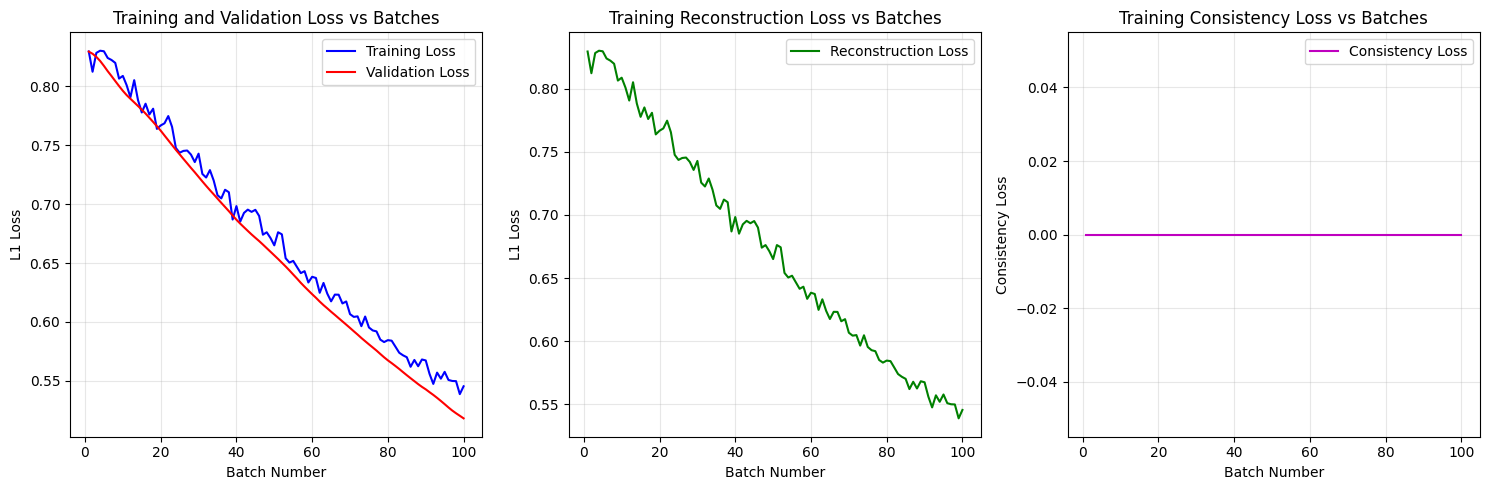

In [36]:
# Train the model using the fixed training function
print("\n" + "="*80)
print("Training attention model on transcriptomics...")
print("="*80 + "\n")

history_dynamics = train_attention_model(
    model=model_transcriptomics,
    train_dataset=train_dataset_transcriptomics,
    val_dataset=val_dataset_transcriptomics,
    config=CONFIG_TRANSCRIPTOMICS,
    device=device
)

# Plot training curves
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.plot(history_dynamics['batch_numbers'], history_dynamics['train_losses'], 'b-', label='Training Loss')
plt.plot(history_dynamics['batch_numbers'], history_dynamics['val_losses'], 'r-', label='Validation Loss')
plt.xlabel('Batch Number')
plt.ylabel('L1 Loss')
plt.title('Training and Validation Loss vs Batches')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 2)
plt.plot(history_dynamics['batch_numbers'], history_dynamics['train_recon_losses'], 'g-', label='Reconstruction Loss')
plt.xlabel('Batch Number')
plt.ylabel('L1 Loss')
plt.title('Training Reconstruction Loss vs Batches')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 3)
plt.plot(history_dynamics['batch_numbers'], history_dynamics['train_consist_losses'], 'm-', label='Consistency Loss')
plt.xlabel('Batch Number')
plt.ylabel('Consistency Loss')
plt.title('Training Consistency Loss vs Batches')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Visualization of Learned Attention Matrices

Now we visualize the learned attention patterns. The attention weights represent our learned "connectome" - how much each neuron needs to attend to every other neuron for reconstruction. We'll focus on analyzing the structure and patterns in the learned attention matrix.


In [38]:
# Updated analyze_attention_matrix function with dictionary unpacking
def analyze_attention_matrix(model, dataset, neuron_labels, device, 
                                         use_attention_scores=False, sparsity_thresh=0.1,
                                         num_graph_targets=20, edge_thresh=0.25):
    """
    Extract and comprehensively analyze learned attention matrix.
    
    Args:
        model: trained SingleHeadSelfAttention or DeepConnectomeTransformer model
        dataset: Dataset used for evaluation
        neuron_labels: list of neuron identifiers
        device: torch device
        use_attention_scores: whether to use scores or weights
        sparsity_thresh: weight threshold for sparsity calculation
        num_graph_targets: number of target neurons for graph visualization
        edge_thresh: weight threshold for edges in graph visualization
    
    Returns:
        dict with attention matrix and comprehensive analysis results
    """
    model.eval()
    
    # Collect attention matrices from all samples
    all_attn_weights = []
    all_attn_scores = []
    loader = DataLoader(dataset, batch_size=32, shuffle=False)
    
    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            # UPDATED: Use dictionary unpacking
            outputs = model(batch, attn_dropout=0.0)
            attn_weights = outputs['attn_weights']
            attn_scores = outputs['attn_scores']
            all_attn_weights.append(attn_weights.cpu().numpy())
            all_attn_scores.append(attn_scores.cpu().numpy())
    
    # Average across all samples
    all_attn_weights = np.concatenate(all_attn_weights, axis=0)
    all_attn_scores = np.concatenate(all_attn_scores, axis=0)
    
    # Take mean across batch dimension
    attention_weights_matrix = np.mean(all_attn_weights, axis=0)
    attention_scores_matrix = np.mean(all_attn_scores, axis=0)
    
    # Choose which matrix to analyze
    if use_attention_scores:
        attention_matrix = attention_scores_matrix
        matrix_type = "scores"
    else:
        attention_matrix = attention_weights_matrix
        matrix_type = "weights"
    
    # Basic statistics
    mean_val = np.mean(attention_matrix)
    std_val = np.std(attention_matrix)
    max_val = np.max(attention_matrix)
    sparsity = np.sum(attention_matrix < sparsity_thresh) / attention_matrix.size
    
    print(f"\\nAttention Matrix Analysis ({matrix_type}):")
    print(f"  Shape: {attention_matrix.shape}")
    print(f"  Mean: {mean_val:.6f}")
    print(f"  Std: {std_val:.6f}")
    print(f"  Max: {max_val:.6f}")
    print(f"  Sparsity (< {sparsity_thresh}): {sparsity:.3f}")
    
    # Create comprehensive visualization
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    
    # 1) Full attention matrix heatmap
    im1 = axes[0, 0].imshow(attention_matrix, cmap='viridis', aspect='auto')
    axes[0, 0].set_title(f'Learned Attention Matrix ({matrix_type.title()})', fontsize=12, fontweight='bold')
    axes[0, 0].set_xlabel('Target Neuron')
    axes[0, 0].set_ylabel('Source Neuron')
    plt.colorbar(im1, ax=axes[0, 0], label=f'Attention {matrix_type.title()}')
    
    # 2) Attention distribution
    axes[0, 1].hist(attention_matrix.flatten(), bins=50, alpha=0.7, color='skyblue', edgecolor='black')
    axes[0, 1].set_title(f'Attention {matrix_type.title()} Distribution', fontsize=12, fontweight='bold')
    axes[0, 1].set_xlabel(f'Attention {matrix_type.title()}')
    axes[0, 1].set_ylabel('Frequency')
    axes[0, 1].axvline(sparsity_thresh, color='red', linestyle='--', label=f'Sparsity threshold ({sparsity_thresh})')
    axes[0, 1].legend()
    
    # 3) Row-wise statistics
    row_means = np.mean(attention_matrix, axis=1)
    row_stds = np.std(attention_matrix, axis=1)
    axes[0, 2].scatter(row_means, row_stds, alpha=0.7, s=30)
    axes[0, 2].set_title('Row-wise Statistics', fontsize=12, fontweight='bold')
    axes[0, 2].set_xlabel('Mean Attention Weight')
    axes[0, 2].set_ylabel('Std Attention Weight')
    
    # 4) Network graph visualization
    G = nx.DiGraph()
    n_neurons = len(neuron_labels)
    
    # Add nodes
    for i, label in enumerate(neuron_labels):
        G.add_node(i, label=label)
    
    # Add edges above threshold
    for i in range(n_neurons):
        for j in range(n_neurons):
            if attention_matrix[i, j] > edge_thresh:
                G.add_edge(i, j, weight=attention_matrix[i, j])
    
    # Select top target neurons by total incoming attention
    incoming_attention = np.sum(attention_matrix, axis=0)
    top_targets = np.argsort(incoming_attention)[-num_graph_targets:]
    
    # Create subgraph with top targets and their connections
    subgraph_nodes = set(top_targets)
    for target in top_targets:
        # Add all neurons that attend to this target
        subgraph_nodes.update(np.where(attention_matrix[:, target] > edge_thresh)[0])
        # Add all neurons this target attends to
        subgraph_nodes.update(np.where(attention_matrix[target, :] > edge_thresh)[0])
    
    subgraph = G.subgraph(subgraph_nodes)
    
    # Layout and draw
    pos = nx.spring_layout(subgraph, k=1, iterations=50)
    node_colors = ['red' if node in top_targets else 'lightblue' for node in subgraph.nodes()]
    
    nx.draw(subgraph, pos, ax=axes[1, 0], 
            node_color=node_colors, 
            node_size=100,
            with_labels=False,
            edge_color='gray',
            alpha=0.7)
    axes[1, 0].set_title(f'Attention Network (Top {num_graph_targets} Targets)', fontsize=12, fontweight='bold')
    
    # 5) Column-wise statistics
    col_means = np.mean(attention_matrix, axis=0)
    col_stds = np.std(attention_matrix, axis=0)
    axes[1, 1].scatter(col_means, col_stds, alpha=0.7, s=30)
    axes[1, 1].set_title('Column-wise Statistics', fontsize=12, fontweight='bold')
    axes[1, 1].set_xlabel('Mean Attention Weight')
    axes[1, 1].set_ylabel('Std Attention Weight')
    
    # 6) Summary statistics
    axes[1, 2].axis('off')
    summary_text = f"""Attention Matrix Summary:
    
Matrix Type: {matrix_type.title()}
Shape: {attention_matrix.shape}
Mean: {mean_val:.6f}
Std: {std_val:.6f}
Max: {max_val:.6f}
Sparsity: {sparsity:.3f}

Network Statistics:
Total Nodes: {len(subgraph.nodes())}
Total Edges: {len(subgraph.edges())}
Top Targets: {num_graph_targets}
Edge Threshold: {edge_thresh}

Neuron Labels: {len(neuron_labels)}"""
    
    axes[1, 2].text(0.1, 0.5, summary_text, fontsize=10, verticalalignment='center',
                    bbox=dict(boxstyle="round,pad=0.3", facecolor="lightgray", alpha=0.7))
    
    plt.tight_layout()
    plt.show()
    
    return {
        'attention_matrix': attention_matrix,
        'attention_weights': attention_weights_matrix,
        'attention_scores': attention_scores_matrix,
        'mean': mean_val,
        'std': std_val,
        'max': max_val,
        'sparsity': sparsity,
        'network': subgraph,
        'top_targets': top_targets
    }



Analyzing learned attention matrix from transcriptomics phase...
\nAttention Matrix Analysis (weights):
  Shape: (130, 130)
  Mean: 0.007692
  Std: 0.008720
  Max: 0.157097
  Sparsity (< 0.1): 1.000


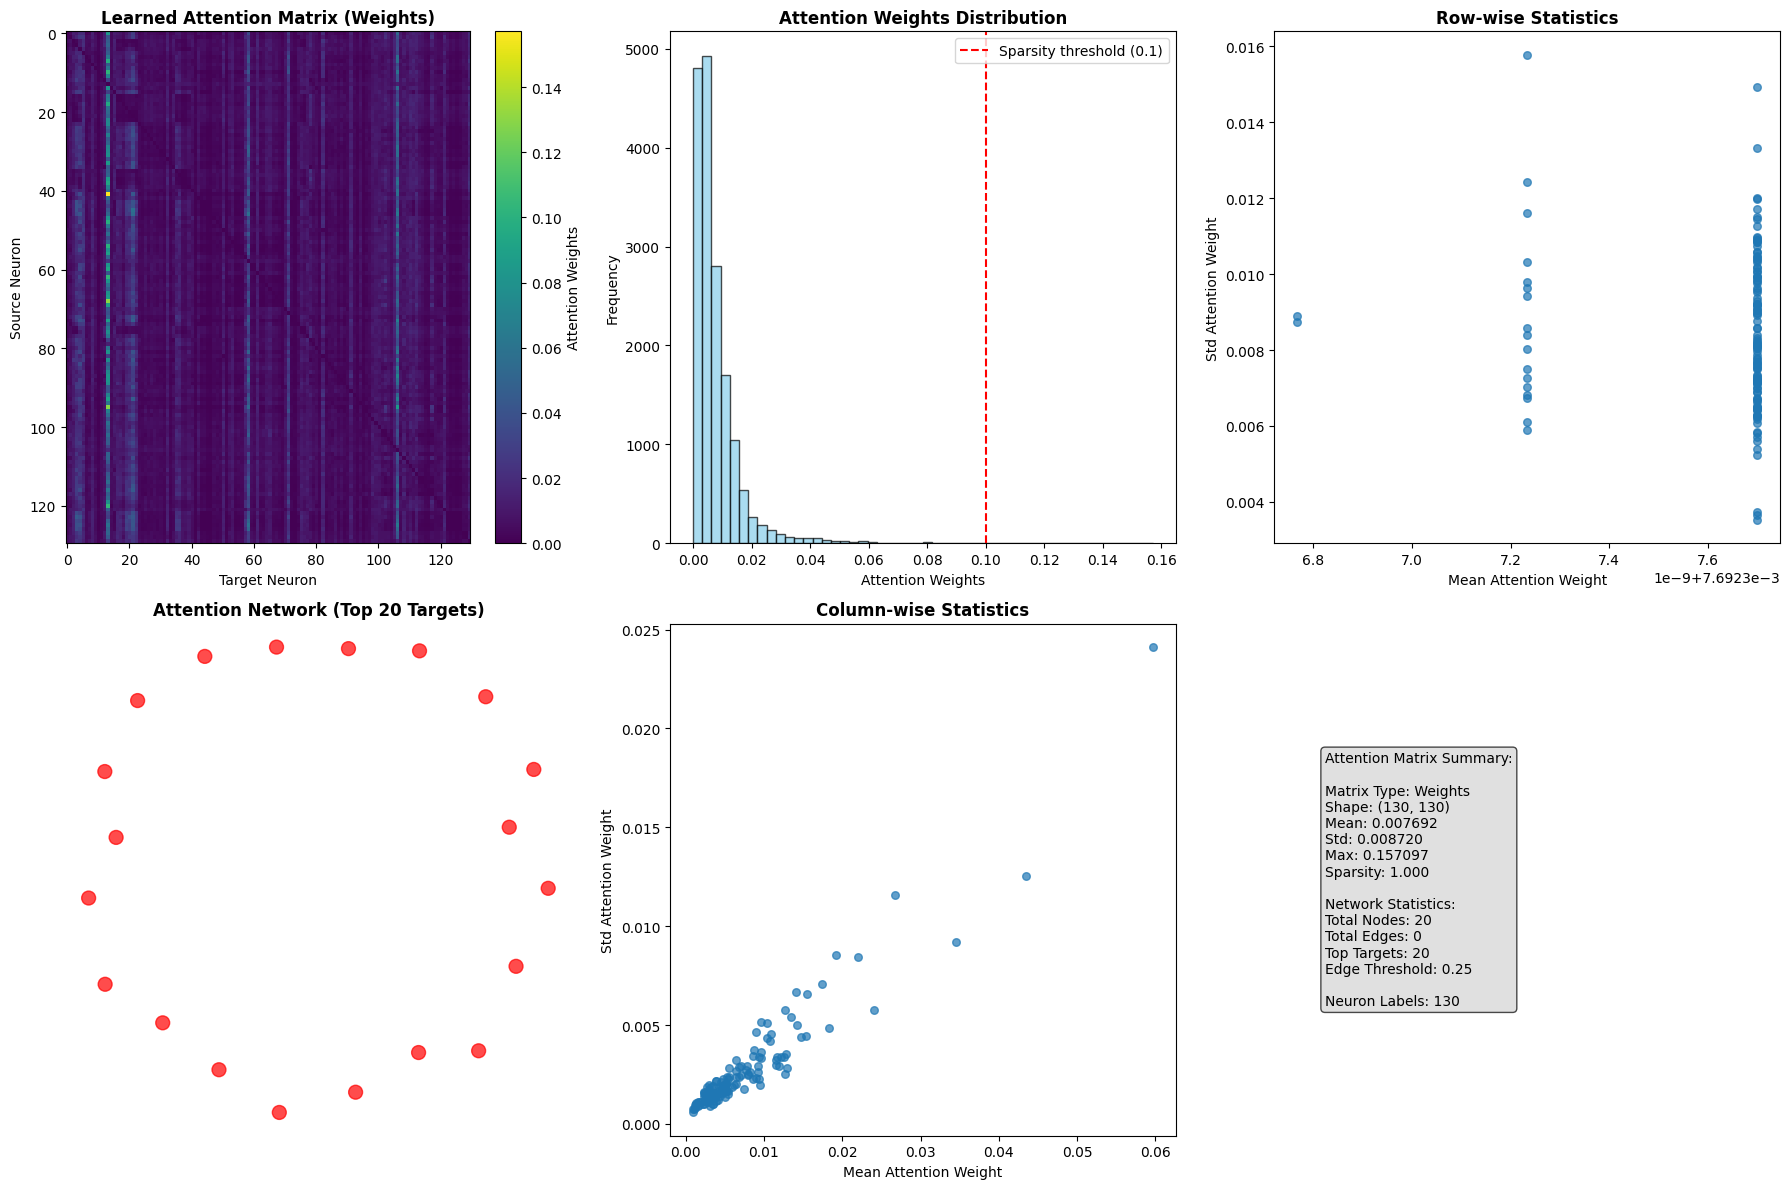

In [39]:
# Replace the transcriptomics visualization with modularized function
print("Analyzing learned attention matrix from transcriptomics phase...")

# Analyze using the comprehensive function
results_transcriptomics = analyze_attention_matrix(
    model=model_transcriptomics,
    dataset=val_dataset_transcriptomics,
    neuron_labels=neuron_classes,
    device=device,
    use_attention_scores=CONFIG_TRANSCRIPTOMICS['use_attention_scores'],
    sparsity_thresh=0.1,
    num_graph_targets=20,
    edge_thresh=0.25
)

# Store results for later comparison
attention_matrix_transcriptomics = results_transcriptomics['attention_matrix']


### **Idea**: Does the learned attention matrix better embed neurons? 

If we interpret the attention matrix as a similarity matrix, does it induce a semantically meaningful clustering of neurons, such as by cell-type or neurotransmitters?

We can load additional neuron metadata from `data/neuron_master_sheet.csv` to use as unsupervised labels.

In [ ]:
# Similarity → Information Distance → Classical MDS
# - Use the learned attention matrix A (rows softmaxed)
# - Symmetrize to get similarity S in [0,1]
# - Convert S to a steeper "information" distance with -log
# - Classical MDS from distances

# ----- Use the learned attention matrix -----
A = attention_matrix_transcriptomics

# Symmetrize to get a similarity matrix S \in [0,1]
# S = 0.5 * (A + A.T)

# If the learnt attention matrix is already approximately symmetric
S = A 
n = S.shape[0]
J = np.eye(n) - np.ones((n, n)) / n

# ----- Similarity -> Distance (steeper than sqrt(1-S)) -----
# Information distance: D_ij = sqrt(max(0, -log(S_ij + eps)))
eps = 1e-9
D = np.sqrt(np.maximum(0.0, -np.log(S + eps)))

# ----- Classical MDS from pairwise distances -----
# Double-centering turns squared distances into a centered Gram matrix
B = -0.5 * J @ (D ** 2) @ J

# Eigendecomposition of Gram matrix; take top 2 components
eigvals, eigvecs = np.linalg.eigh(B)
idx = np.argsort(eigvals)[::-1]
eigvals, eigvecs = eigvals[idx], eigvecs[:, idx]

# Keep top 2 nonnegative components (guard against tiny negatives)
k = min(2, int((eigvals > 1e-12).sum()))
coords_mds = eigvecs[:, :k] * np.sqrt(np.maximum(eigvals[:k], 0.0))

# ----- Plot: 3-panel visualization with metadata coloring -----
fig, axes = plt.subplots(1, 3, figsize=(21, 12))

# Create a consistent color mapping for neurons
unique_colors = plt.cm.tab20(np.linspace(0, 1, len(neuron_classes)))
color_dict = dict(zip(neuron_classes, unique_colors))
colors = [color_dict[neuron] for neuron in neuron_classes]

# Plot 1: By neuron index
ax = axes[0]
scatter = ax.scatter(coords_mds[:, 0], coords_mds[:, 1],
                    c=range(len(neuron_classes)), cmap='tab20', s=60, alpha=0.8)
ax.set_title('MDS from Attention (-log) - By Neuron Index', fontsize=14, fontweight='bold')
ax.set_xlabel('MDS Dim 1')
ax.set_ylabel('MDS Dim 2')
ax.set_aspect('equal')

# Annotate every other point in first plot
for i in range(0, len(neuron_classes), 2):
    ax.annotate(neuron_classes[i], (coords_mds[i, 0], coords_mds[i, 1]),
                xytext=(5, 5), textcoords='offset points', fontsize=8, alpha=0.8)

# Plot 2: By neurotransmitter
ax = axes[1]
scatter = ax.scatter(coords_mds[:, 0], coords_mds[:, 1],
                    c=nt_color_values, s=60, alpha=0.8)
ax.set_title('MDS from Attention (-log) - By Neurotransmitter', fontsize=14, fontweight='bold')
ax.set_xlabel('MDS Dim 1')
ax.set_ylabel('MDS Dim 2')
ax.set_aspect('equal')

# Add legend for neurotransmitters
handles = [plt.Line2D([0], [0], marker='o', color='w', 
                     markerfacecolor=plt.cm.tab20(nt_to_color[nt]/len(unique_nt)), 
                     markersize=8, label=nt) for nt in unique_nt]
ax.legend(handles=handles, loc='best', fontsize=8)

# Plot 3: By cell type
ax = axes[2]
scatter = ax.scatter(coords_mds[:, 0], coords_mds[:, 1],
                    c=cls_color_values, s=60, alpha=0.8)
ax.set_title('MDS from Attention (-log) - By Cell Type', fontsize=14, fontweight='bold')
ax.set_xlabel('MDS Dim 1')
ax.set_ylabel('MDS Dim 2')
ax.set_aspect('equal')

# For each unique cell type, find one representative point and annotate it
for cls in unique_cls:
    # Find first neuron of this class
    idx = next(i for i, c in enumerate(neuron_classes) if c == cls)
    ax.annotate(cls, (coords_mds[idx, 0], coords_mds[idx, 1]),
                xytext=(5, 5), textcoords='offset points', fontsize=8, alpha=0.8)

plt.tight_layout()
plt.show()


## 8. Ground-Truth Connectome Data Loading and Analysis

Now we'll load and analyze ground-truth connectome data to compare with our learned attention matrix. We have access to:

1. **Witvliet 2020 data** (`witvliet_2020_7.csv`, `witvliet_2020_8.csv`): From "Connectomes across development reveal principles of brain maturation" (Nature 596, 257–261, 2021)
2. **Randi 2023 data** (`CElegansFunctionalConnectivity.xlsx`): From "Neural signal propagation atlas of Caenorhabditis elegans" (Nature 623, 406–414, 2023)

These provide both structural (wired) and functional connectivity data that we can compare against our learned attention patterns.


In [ ]:
# ============================================================================
# MODULARIZED MATRIX COMPARISON AND VISUALIZATION FUNCTIONS
# ============================================================================

def create_adjacency_matrix(connectome_df, neuron_list, weight_col='synapses', synapse_type='chemical'):
    """
    Create adjacency matrix from connectome dataframe.
    
    Args:
        connectome_df: DataFrame with columns ['pre', 'post', 'type', 'weight']
        neuron_list: List of neuron names in desired order
        weight_col: Column name for edge weights
        synapse_type: Type of synapse to include ('chemical', 'electrical', 'all')
    
    Returns:
        adjacency_matrix: (N, N) numpy array
    """
    n_neurons = len(neuron_list)
    adjacency_matrix = np.zeros((n_neurons, n_neurons))
    
    # Create mapping from neuron name to index
    neuron_to_idx = {neuron: i for i, neuron in enumerate(neuron_list)}
    
    # Filter by synapse type
    if synapse_type != 'all':
        filtered_df = connectome_df[connectome_df['type'] == synapse_type]
    else:
        filtered_df = connectome_df
    
    # Fill adjacency matrix
    for _, row in filtered_df.iterrows():
        pre_neuron = row['pre']
        post_neuron = row['post']
        weight = row[weight_col]
        
        if pre_neuron in neuron_to_idx and post_neuron in neuron_to_idx:
            pre_idx = neuron_to_idx[pre_neuron]
            post_idx = neuron_to_idx[post_neuron]
            adjacency_matrix[pre_idx, post_idx] += weight
    
    return adjacency_matrix

def visualize_attention_vs_ground_truth_comprehensive(
    attention_matrix,
    attention_neuron_labels,
    ground_truth_matrix,
    ground_truth_neuron_labels,
    phase_name="Phase",
    label_to_class_mapping=None,
    exclude_bwm=True
):
    """
    Create comprehensive 2x2 visualization comparing learned attention with ground-truth connectome.
    
    Shows:
    - Top-left: Full ground-truth connectome matrix
    - Top-right: Full learned attention matrix
    - Bottom-left: Ground-truth submatrix (overlapping neurons only)
    - Bottom-right: Attention submatrix (overlapping neurons only)
    
    Args:
        attention_matrix: (N_attn, N_attn) learned attention matrix
        attention_neuron_labels: List of neuron labels for attention matrix
        ground_truth_matrix: (N_gt, N_gt) ground-truth connectome adjacency matrix
        ground_truth_neuron_labels: List of neuron labels for ground-truth matrix
        phase_name: String describing the phase (e.g., "Transcriptomics", "Neural Dynamics")
        label_to_class_mapping: Optional dict mapping neuron member labels to class names
        exclude_bwm: Whether to exclude BWM (body-wall muscle) neurons from overlap calculation
    
    Returns:
        dict containing:
            - 'overlap_neurons': sorted list of overlapping neuron labels
            - 'gt_submatrix': ground-truth submatrix for overlapping neurons
            - 'attention_submatrix': attention submatrix for overlapping neurons
            - 'statistics': dict with matrix statistics
    """
    print(f"\n" + "="*80)
    print(f"COMPREHENSIVE MATRIX VISUALIZATION: {phase_name.upper()}")
    print("="*80 + "\n")
    
    # Process attention neuron labels
    if exclude_bwm:
        attention_neurons = {n for n in attention_neuron_labels if not n.startswith('BWM-')}
    else:
        attention_neurons = set(attention_neuron_labels)
    
    # Apply label-to-class mapping if provided
    if label_to_class_mapping:
        attention_neurons |= {label_to_class_mapping[mem] for mem in attention_neurons 
                             if mem in label_to_class_mapping}
    
    # Process ground-truth neuron labels
    if exclude_bwm:
        gt_neurons = {n for n in ground_truth_neuron_labels if not n.startswith('BWM-')}
    else:
        gt_neurons = set(ground_truth_neuron_labels)
    
    # Apply label-to-class mapping if provided
    if label_to_class_mapping:
        gt_neurons |= {label_to_class_mapping[mem] for mem in gt_neurons 
                      if mem in label_to_class_mapping}
    
    # Find overlapping neurons
    overlap_neurons = attention_neurons.intersection(gt_neurons)
    overlap_neurons_sorted = sorted(list(overlap_neurons))
    
    print(f"Attention neurons: {len(attention_neurons)}")
    print(f"Ground-truth neurons: {len(gt_neurons)}")
    print(f"Overlapping neurons: {len(overlap_neurons_sorted)}")
    print(f"Overlap percentage: {len(overlap_neurons_sorted) / max(len(attention_neurons), len(gt_neurons)) * 100:.1f}%")
    
    if len(overlap_neurons_sorted) == 0:
        print("⚠️  No overlapping neurons found!")
        return {
            'overlap_neurons': [],
            'gt_submatrix': np.array([]),
            'attention_submatrix': np.array([]),
            'statistics': {}
        }
    
    # Get indices for submatrices
    attention_indices = [attention_neuron_labels.index(n) for n in overlap_neurons_sorted 
                        if n in attention_neuron_labels]
    gt_indices = [ground_truth_neuron_labels.index(n) for n in overlap_neurons_sorted 
                 if n in ground_truth_neuron_labels]
    
    # Extract submatrices
    attention_submatrix = attention_matrix[np.ix_(attention_indices, attention_indices)]
    gt_submatrix = ground_truth_matrix[np.ix_(gt_indices, gt_indices)]
    
    # Create 2x2 subplot visualization
    fig, axes = plt.subplots(2, 2, figsize=(24, 20))
    
    # Top row: Full matrices
    # 1) Full ground-truth connectome
    im1 = axes[0, 0].imshow(ground_truth_matrix, cmap='viridis', aspect='auto')
    axes[0, 0].set_title('Full Ground-Truth Connectome\n(Witvliet 2020 Combined)', fontsize=14, fontweight='bold')
    axes[0, 0].set_xlabel('Target Neuron')
    axes[0, 0].set_ylabel('Source Neuron')
    plt.colorbar(im1, ax=axes[0, 0], label='Synapse Count')
    
    # Label every k-th tick to reduce clutter for full matrix
    k_full = max(1, len(ground_truth_neuron_labels) // 20)  # ~20 labels per axis
    xticks_full = np.arange(0, len(ground_truth_neuron_labels), k_full)
    axes[0, 0].set_xticks(xticks_full)
    axes[0, 0].set_xticklabels([ground_truth_neuron_labels[i] for i in xticks_full], fontsize=6, rotation=90)
    axes[0, 0].set_yticks(xticks_full)
    axes[0, 0].set_yticklabels([ground_truth_neuron_labels[i] for i in xticks_full], fontsize=6)
    
    # 2) Full learned attention matrix
    im2 = axes[0, 1].imshow(attention_matrix, cmap='plasma', aspect='auto')
    axes[0, 1].set_title(f'Full Learned Attention Matrix\n({phase_name} Phase)', fontsize=14, fontweight='bold')
    axes[0, 1].set_xlabel('Target Neuron')
    axes[0, 1].set_ylabel('Source Neuron')
    plt.colorbar(im2, ax=axes[0, 1], label='Attention Weight')
    
    # Label every k-th tick to reduce clutter for full matrix
    k_attn = max(1, len(attention_neuron_labels) // 20)  # ~20 labels per axis
    xticks_attn = np.arange(0, len(attention_neuron_labels), k_attn)
    axes[0, 1].set_xticks(xticks_attn)
    axes[0, 1].set_xticklabels([attention_neuron_labels[i] for i in xticks_attn], fontsize=6, rotation=90)
    axes[0, 1].set_yticks(xticks_attn)
    axes[0, 1].set_yticklabels([attention_neuron_labels[i] for i in xticks_attn], fontsize=6)
    
    # Bottom row: Submatrices (overlapping neurons)
    # 3) Ground-truth submatrix
    im3 = axes[1, 0].imshow(gt_submatrix, cmap='viridis', aspect='auto')
    axes[1, 0].set_title(f'Ground-Truth Submatrix\n({len(overlap_neurons_sorted)} Overlapping Neurons)', fontsize=14, fontweight='bold')
    axes[1, 0].set_xlabel('Target Neuron')
    axes[1, 0].set_ylabel('Source Neuron')
    plt.colorbar(im3, ax=axes[1, 0], label='Synapse Count')
    
    # Label all neurons in submatrix (should be manageable)
    axes[1, 0].set_xticks(range(len(overlap_neurons_sorted)))
    axes[1, 0].set_xticklabels(overlap_neurons_sorted, fontsize=8, rotation=90)
    axes[1, 0].set_yticks(range(len(overlap_neurons_sorted)))
    axes[1, 0].set_yticklabels(overlap_neurons_sorted, fontsize=8)
    
    # 4) Attention submatrix
    im4 = axes[1, 1].imshow(attention_submatrix, cmap='plasma', aspect='auto')
    axes[1, 1].set_title(f'Attention Submatrix\n({len(overlap_neurons_sorted)} Overlapping Neurons)', fontsize=14, fontweight='bold')
    axes[1, 1].set_xlabel('Target Neuron')
    axes[1, 1].set_ylabel('Source Neuron')
    plt.colorbar(im4, ax=axes[1, 1], label='Attention Weight')
    
    # Label all neurons in submatrix
    axes[1, 1].set_xticks(range(len(overlap_neurons_sorted)))
    axes[1, 1].set_xticklabels(overlap_neurons_sorted, fontsize=8, rotation=90)
    axes[1, 1].set_yticks(range(len(overlap_neurons_sorted)))
    axes[1, 1].set_yticklabels(overlap_neurons_sorted, fontsize=8)
    
    plt.tight_layout()
    plt.show()
    
    # Print comprehensive statistics
    print("\n" + "="*60)
    print("MATRIX STATISTICS COMPARISON")
    print("="*60)
    
    print(f"\nFULL MATRICES:")
    print(f"Ground-Truth Connectome:")
    print(f"  Shape: {ground_truth_matrix.shape}")
    print(f"  Mean: {ground_truth_matrix.mean():.6f}")
    print(f"  Std: {ground_truth_matrix.std():.6f}")
    print(f"  Max: {ground_truth_matrix.max():.1f}")
    print(f"  Sparsity: {(ground_truth_matrix == 0).sum() / ground_truth_matrix.size:.3f}")
    
    print(f"\nLearned Attention Matrix:")
    print(f"  Shape: {attention_matrix.shape}")
    print(f"  Mean: {attention_matrix.mean():.6f}")
    print(f"  Std: {attention_matrix.std():.6f}")
    print(f"  Max: {attention_matrix.max():.6f}")
    print(f"  Sparsity: {(attention_matrix < 0.01).sum() / attention_matrix.size:.3f}")
    
    print(f"\nSUBMATRICES (Overlapping Neurons):")
    print(f"Ground-Truth Submatrix:")
    print(f"  Shape: {gt_submatrix.shape}")
    print(f"  Mean: {gt_submatrix.mean():.6f}")
    print(f"  Std: {gt_submatrix.std():.6f}")
    print(f"  Max: {gt_submatrix.max():.1f}")
    print(f"  Sparsity: {(gt_submatrix == 0).sum() / gt_submatrix.size:.3f}")
    
    print(f"\nAttention Submatrix:")
    print(f"  Shape: {attention_submatrix.shape}")
    print(f"  Mean: {attention_submatrix.mean():.6f}")
    print(f"  Std: {attention_submatrix.std():.6f}")
    print(f"  Max: {attention_submatrix.max():.6f}")
    print(f"  Sparsity: {(attention_submatrix < 0.01).sum() / attention_submatrix.size:.3f}")
    
    print(f"\nOVERLAP INFORMATION:")
    print(f"Total neurons in ground-truth: {len(ground_truth_neuron_labels)}")
    print(f"Total neurons in attention: {len(attention_neuron_labels)}")
    print(f"Overlapping neurons: {len(overlap_neurons_sorted)}")
    print(f"Overlap percentage: {len(overlap_neurons_sorted) / max(len(ground_truth_neuron_labels), len(attention_neuron_labels)) * 100:.1f}%")
    
    # Return results for potential downstream analysis
    statistics = {
        'gt_full': {
            'shape': ground_truth_matrix.shape,
            'mean': ground_truth_matrix.mean(),
            'std': ground_truth_matrix.std(),
            'max': ground_truth_matrix.max(),
            'sparsity': (ground_truth_matrix == 0).sum() / ground_truth_matrix.size
        },
        'attention_full': {
            'shape': attention_matrix.shape,
            'mean': attention_matrix.mean(),
            'std': attention_matrix.std(),
            'max': attention_matrix.max(),
            'sparsity': (attention_matrix < 0.01).sum() / attention_matrix.size
        },
        'gt_submatrix': {
            'shape': gt_submatrix.shape,
            'mean': gt_submatrix.mean(),
            'std': gt_submatrix.std(),
            'max': gt_submatrix.max(),
            'sparsity': (gt_submatrix == 0).sum() / gt_submatrix.size
        },
        'attention_submatrix': {
            'shape': attention_submatrix.shape,
            'mean': attention_submatrix.mean(),
            'std': attention_submatrix.std(),
            'max': attention_submatrix.max(),
            'sparsity': (attention_submatrix < 0.01).sum() / attention_submatrix.size
        },
        'overlap_info': {
            'total_gt_neurons': len(ground_truth_neuron_labels),
            'total_attention_neurons': len(attention_neuron_labels),
            'overlapping_neurons': len(overlap_neurons_sorted),
            'overlap_percentage': len(overlap_neurons_sorted) / max(len(ground_truth_neuron_labels), len(attention_neuron_labels)) * 100
        }
    }
    
    return {
        'overlap_neurons': overlap_neurons_sorted,
        'gt_submatrix': gt_submatrix,
        'attention_submatrix': attention_submatrix,
        'statistics': statistics
    }

def compare_attention_with_ground_truth(attention_matrix, attention_neuron_labels, 
                                     ground_truth_matrices, ground_truth_neuron_labels,
                                     phase_name="Unknown Phase", 
                                     label_to_class_mapping=None,
                                     exclude_bwm=True):
    """
    Comprehensive comparison between learned attention matrix and ground-truth connectomes.
    
    Args:
        attention_matrix: (N, N) learned attention matrix
        attention_neuron_labels: List of neuron labels for attention matrix
        ground_truth_matrices: Dict of {'name': matrix} for ground-truth connectomes
        ground_truth_neuron_labels: Dict of {'name': labels} for ground-truth matrices
        phase_name: String describing the phase (e.g., "Transcriptomics", "Neural Dynamics")
        label_to_class_mapping: Optional dict mapping neuron labels to class names
        exclude_bwm: Whether to exclude BWM (body-wall muscle) neurons
    
    Returns:
        results: Dict containing comparison results and visualizations
    """
    print(f"\n" + "="*80)
    print(f"COMPREHENSIVE MATRIX COMPARISON: {phase_name.upper()}")
    print("="*80 + "\n")
    
    results = {
        'phase_name': phase_name,
        'attention_matrix': attention_matrix,
        'attention_neuron_labels': attention_neuron_labels,
        'comparisons': {}
    }
    
    # Process attention neuron labels
    if exclude_bwm:
        attention_neurons = {n for n in attention_neuron_labels if not n.startswith('BWM-')}
    else:
        attention_neurons = set(attention_neuron_labels)
    
    # Apply label-to-class mapping if provided
    if label_to_class_mapping:
        attention_neurons |= {label_to_class_mapping[mem] for mem in attention_neurons 
                             if mem in label_to_class_mapping}
    
    # Compare with each ground-truth connectome
    for gt_name, gt_matrix in ground_truth_matrices.items():
        print(f"\n{'='*60}")
        print(f"COMPARING WITH {gt_name.upper()}")
        print(f"{'='*60}")
        
        gt_labels = ground_truth_neuron_labels[gt_name]
        
        # Process ground-truth neuron labels
        if exclude_bwm:
            gt_neurons = {n for n in gt_labels if not n.startswith('BWM-')}
        else:
            gt_neurons = set(gt_labels)
        
        # Apply label-to-class mapping if provided
        if label_to_class_mapping:
            gt_neurons |= {label_to_class_mapping[mem] for mem in gt_neurons 
                          if mem in label_to_class_mapping}
        
        # Find overlapping neurons
        overlap_neurons = attention_neurons.intersection(gt_neurons)
        
        print(f"Attention neurons: {len(attention_neurons)}")
        print(f"Ground-truth neurons: {len(gt_neurons)}")
        print(f"Overlapping neurons: {len(overlap_neurons)}")
        print(f"Overlap percentage: {len(overlap_neurons) / max(len(attention_neurons), len(gt_neurons)) * 100:.1f}%")
        
        if len(overlap_neurons) == 0:
            print(f"⚠️  No overlapping neurons found with {gt_name}")
            results['comparisons'][gt_name] = {
                'overlap_count': 0,
                'correlation': np.nan,
                'p_value': np.nan,
                'overlap_neurons': []
            }
            continue
        
        # Create submatrices for overlapping neurons
        overlap_neurons_sorted = sorted(list(overlap_neurons))
        
        # Get indices for attention matrix
        attention_indices = [attention_neuron_labels.index(n) for n in overlap_neurons_sorted 
                            if n in attention_neuron_labels]
        
        # Get indices for ground-truth matrix
        gt_indices = [gt_labels.index(n) for n in overlap_neurons_sorted 
                     if n in gt_labels]
        
        # Extract submatrices
        attention_submatrix = attention_matrix[np.ix_(attention_indices, attention_indices)]
        gt_submatrix = gt_matrix[np.ix_(gt_indices, gt_indices)]
        
        print(f"Submatrix shapes: Attention {attention_submatrix.shape}, GT {gt_submatrix.shape}")        
        
        # Flatten matrices and remove diagonal
        mask = ~np.eye(attention_submatrix.shape[0], dtype=bool)
        attn_flat = attention_submatrix[mask]
        gt_flat = gt_submatrix[mask]
        
        # Remove any NaN values
        valid_mask = ~(np.isnan(attn_flat) | np.isnan(gt_flat))
        attn_valid = attn_flat[valid_mask]
        gt_valid = gt_flat[valid_mask]
        
        if len(attn_valid) > 1:
            correlation, p_value = pearsonr(attn_valid, gt_valid)
        else:
            correlation, p_value = np.nan, np.nan
        
        print(f"Correlation: r = {correlation:.4f}, p = {p_value:.2e}")
        print(f"Valid data points: {len(attn_valid)}/{len(attn_flat)}")
        
        # Store results
        results['comparisons'][gt_name] = {
            'overlap_count': len(overlap_neurons),
            'correlation': correlation,
            'p_value': p_value,
            'overlap_neurons': overlap_neurons_sorted,
            'attention_submatrix': attention_submatrix,
            'gt_submatrix': gt_submatrix,
            'valid_data_points': len(attn_valid)
        }
    
    # Create comprehensive visualization
    _create_comprehensive_matrix_visualization(results, ground_truth_matrices, ground_truth_neuron_labels)
    
    return results

def _create_comprehensive_matrix_visualization(results, ground_truth_matrices, ground_truth_neuron_labels):
    """
    Create comprehensive visualization comparing attention matrix with ground-truth connectomes.
    """
    phase_name = results['phase_name']
    attention_matrix = results['attention_matrix']
    attention_neuron_labels = results['attention_neuron_labels']
    
    # Determine layout based on number of ground-truth matrices
    n_gt = len(ground_truth_matrices)
    if n_gt == 1:
        fig, axes = plt.subplots(2, 2, figsize=(20, 16))
        axes = axes.flatten()
    else:
        fig, axes = plt.subplots(2, n_gt + 1, figsize=(6 * (n_gt + 1), 16))
    
    # Plot 1: Full attention matrix
    im1 = axes[0].imshow(attention_matrix, cmap='plasma', aspect='auto')
    axes[0].set_title(f'Learned Attention Matrix\n({phase_name})', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Target Neuron')
    axes[0].set_ylabel('Source Neuron')
    plt.colorbar(im1, ax=axes[0], label='Attention Weight')
    
    # Add neuron labels (every k-th to reduce clutter)
    k = max(1, len(attention_neuron_labels) // 20)
    xticks = np.arange(0, len(attention_neuron_labels), k)
    axes[0].set_xticks(xticks)
    axes[0].set_xticklabels([attention_neuron_labels[i] for i in xticks], fontsize=6, rotation=90)
    axes[0].set_yticks(xticks)
    axes[0].set_yticklabels([attention_neuron_labels[i] for i in xticks], fontsize=6)
    
    # Plot ground-truth matrices
    for i, (gt_name, gt_matrix) in enumerate(ground_truth_matrices.items()):
        gt_labels = ground_truth_neuron_labels[gt_name]
        
        # Full ground-truth matrix
        im_gt = axes[i + 1].imshow(gt_matrix, cmap='viridis', aspect='auto')
        axes[i + 1].set_title(f'Ground-Truth Connectome\n({gt_name})', fontsize=14, fontweight='bold')
        axes[i + 1].set_xlabel('Target Neuron')
        axes[i + 1].set_ylabel('Source Neuron')
        plt.colorbar(im_gt, ax=axes[i + 1], label='Synapse Count')
        
        # Add neuron labels
        k_gt = max(1, len(gt_labels) // 20)
        xticks_gt = np.arange(0, len(gt_labels), k_gt)
        axes[i + 1].set_xticks(xticks_gt)
        axes[i + 1].set_xticklabels([gt_labels[j] for j in xticks_gt], fontsize=6, rotation=90)
        axes[i + 1].set_yticks(xticks_gt)
        axes[i + 1].set_yticklabels([gt_labels[j] for j in xticks_gt], fontsize=6)
    
    # Plot submatrices (overlapping neurons)
    start_idx = n_gt + 1
    for i, (gt_name, comparison) in enumerate(results['comparisons'].items()):
        if comparison['overlap_count'] == 0:
            continue
            
        overlap_neurons = comparison['overlap_neurons']
        attention_submatrix = comparison['attention_submatrix']
        gt_submatrix = comparison['gt_submatrix']
        
        # Attention submatrix
        im_attn_sub = axes[start_idx + i * 2].imshow(attention_submatrix, cmap='plasma', aspect='auto')
        axes[start_idx + i * 2].set_title(f'Attention Submatrix\n({len(overlap_neurons)} overlapping)', 
                                         fontsize=12, fontweight='bold')
        axes[start_idx + i * 2].set_xlabel('Target Neuron')
        axes[start_idx + i * 2].set_ylabel('Source Neuron')
        plt.colorbar(im_attn_sub, ax=axes[start_idx + i * 2], label='Attention Weight')
        
        # Add all neuron labels for submatrix
        axes[start_idx + i * 2].set_xticks(range(len(overlap_neurons)))
        axes[start_idx + i * 2].set_xticklabels(overlap_neurons, fontsize=8, rotation=90)
        axes[start_idx + i * 2].set_yticks(range(len(overlap_neurons)))
        axes[start_idx + i * 2].set_yticklabels(overlap_neurons, fontsize=8)
        
        # Ground-truth submatrix
        im_gt_sub = axes[start_idx + i * 2 + 1].imshow(gt_submatrix, cmap='viridis', aspect='auto')
        axes[start_idx + i * 2 + 1].set_title(f'GT Submatrix\n({gt_name})', 
                                             fontsize=12, fontweight='bold')
        axes[start_idx + i * 2 + 1].set_xlabel('Target Neuron')
        axes[start_idx + i * 2 + 1].set_ylabel('Source Neuron')
        plt.colorbar(im_gt_sub, ax=axes[start_idx + i * 2 + 1], label='Synapse Count')
        
        # Add all neuron labels for submatrix
        axes[start_idx + i * 2 + 1].set_xticks(range(len(overlap_neurons)))
        axes[start_idx + i * 2 + 1].set_xticklabels(overlap_neurons, fontsize=8, rotation=90)
        axes[start_idx + i * 2 + 1].set_yticks(range(len(overlap_neurons)))
        axes[start_idx + i * 2 + 1].set_yticklabels(overlap_neurons, fontsize=8)
    
    plt.tight_layout()
    plt.show()
    
    # Print comprehensive statistics
    print(f"\n" + "="*60)
    print(f"MATRIX STATISTICS: {phase_name.upper()}")
    print("="*60)
    
    print(f"\nLEARNED ATTENTION MATRIX:")
    print(f"  Shape: {attention_matrix.shape}")
    print(f"  Mean: {attention_matrix.mean():.6f}")
    print(f"  Std: {attention_matrix.std():.6f}")
    print(f"  Max: {attention_matrix.max():.6f}")
    print(f"  Sparsity: {(attention_matrix < 0.01).sum() / attention_matrix.size:.3f}")
    
    for gt_name, comparison in results['comparisons'].items():
        if comparison['overlap_count'] == 0:
            continue
            
        print(f"\n{gt_name.upper()} COMPARISON:")
        print(f"  Overlapping neurons: {comparison['overlap_count']}")
        print(f"  Correlation: r = {comparison['correlation']:.4f}")
        print(f"  P-value: {comparison['p_value']:.2e}")
        print(f"  Valid data points: {comparison['valid_data_points']}")
        
        if 'gt_submatrix' in comparison:
            gt_sub = comparison['gt_submatrix']
            print(f"  GT submatrix - Mean: {gt_sub.mean():.6f}, Std: {gt_sub.std():.6f}, Max: {gt_sub.max():.1f}")
            print(f"  GT submatrix - Sparsity: {(gt_sub == 0).sum() / gt_sub.size:.3f}")
            

In [ ]:
# Load and analyze Witvliet 2020 connectome data
print("Loading Witvliet 2020 connectome data...")

# Load both datasets (they are tab-separated)
witvliet_7 = pd.read_csv('data/connectomics/witvliet_2020_7.csv', sep='\t')
witvliet_8 = pd.read_csv('data/connectomics/witvliet_2020_8.csv', sep='\t')

print(f"Witvliet 2020-7 shape: {witvliet_7.shape}")
print(f"Witvliet 2020-8 shape: {witvliet_8.shape}")
print(f"\nWitvliet 2020-7 columns: {witvliet_7.columns.tolist()}")
print(f"Witvliet 2020-8 columns: {witvliet_8.columns.tolist()}")

# Display sample data
print(f"\nWitvliet 2020-7 sample:")
print(witvliet_7.head())
print(f"\nWitvliet 2020-8 sample:")
print(witvliet_8.head())

# Analyze unique neurons in each dataset, filtering out BWM (body-wall muscle) neurons
neurons_7_pre = {n for n in witvliet_7['pre'].unique() if not n.startswith('BWM-')}
neurons_7_post = {n for n in witvliet_7['post'].unique() if not n.startswith('BWM-')}
neurons_7_all = neurons_7_pre.union(neurons_7_post)

neurons_8_pre = {n for n in witvliet_8['pre'].unique() if not n.startswith('BWM-')}
neurons_8_post = {n for n in witvliet_8['post'].unique() if not n.startswith('BWM-')}
neurons_8_all = neurons_8_pre.union(neurons_8_post)

# Union of all neurons across both datasets
neurons_7_8_all = neurons_7_all.union(neurons_8_all)

# Map class members to their class names since the neuron labels consist of a mixture of class and members
neurons_7_8_all |= {label_to_class[mem] for mem in neurons_7_8_all if mem in label_to_class}  

print(f"\nNeuron analysis:")
print(f"Witvliet 2020-7: {len(neurons_7_all)} unique neurons")
print(f"Witvliet 2020-8: {len(neurons_8_all)} unique neurons")
print(f"Union of Witvliet 2020-7 and 2020-8: {len(neurons_7_8_all)} neurons")



In [ ]:
# Check overlap with our transcriptome neuron classes
transcriptome_neurons = {n for n in neuron_labels if not n.startswith('BWM-')}
overlap_with_transcriptome = transcriptome_neurons.intersection(neurons_7_8_all)

print(f"\nOverlap with transcriptome data:")
print(f"Combined Witvliet overlap: {len(overlap_with_transcriptome)}/{len(transcriptome_neurons)} ({len(overlap_with_transcriptome)/len(transcriptome_neurons)*100:.1f}%)")
print(f"Sample overlapping neurons: {list(overlap_with_transcriptome)[:10]}")

# Analyze connection types
print(f"\nConnection type analysis:")
print(f"Witvliet 2020-7 types: {witvliet_7['type'].value_counts().to_dict()}")
print(f"Witvliet 2020-8 types: {witvliet_8['type'].value_counts().to_dict()}")

# Create full adjacency matrices for all neurons in union (chemical synapses only)
all_neurons = sorted(list(neurons_7_8_all))  # Sort for consistent ordering
print(f"\nCreating adjacency matrices for {len(all_neurons)} neurons...")

print("Witvliet 2020-7:")
gt_adj_7_full = create_adjacency_matrix(witvliet_7, all_neurons, weight_col='synapses', synapse_type='chemical')

print("Witvliet 2020-8:")
gt_adj_8_full = create_adjacency_matrix(witvliet_8, all_neurons, weight_col='synapses', synapse_type='chemical')

# Average element-wise (treating missing connections as 0)
gt_adj_combined = (gt_adj_7_full + gt_adj_8_full) / 2
print(f"\nCombined adjacency matrix shape: {gt_adj_combined.shape}")
print(f"Combined matrix stats - mean: {gt_adj_combined.mean():.6f}, std: {gt_adj_combined.std():.6f}, max: {gt_adj_combined.max():.1f}")

# Extract submatrix for overlapping neurons with transcriptome
overlap_neurons = sorted(list(overlap_with_transcriptome))  # Sort for consistent ordering
print(f"\nUsing {len(overlap_neurons)} overlapping neurons for comparison")

overlap_indices_gt = [all_neurons.index(n) for n in overlap_neurons]
overlap_indices_attn = [neuron_labels.index(n) for n in overlap_neurons]

gt_adj_final = gt_adj_combined[np.ix_(overlap_indices_gt, overlap_indices_gt)]
attention_submatrix = attention_matrix_transcriptomics[np.ix_(overlap_indices_attn, overlap_indices_attn)]

print(f"Ground-truth adjacency matrix (final) shape: {gt_adj_final.shape}")
print(f"Attention submatrix shape: {attention_submatrix.shape}")

print(f"\nFinal matrix statistics:")
print(f"GT Combined (Chemical): mean={gt_adj_final.mean():.6f}, std={gt_adj_final.std():.6f}, max={gt_adj_final.max():.1f}")
print(f"Attention: mean={attention_submatrix.mean():.6f}, std={attention_submatrix.std():.6f}, max={attention_submatrix.max():.6f}")

# Define attention type and label for consistency with visualization code
if CONFIG_TRANSCRIPTOMICS['use_attention_scores']:
    attention_type = "scores"
    attention_label = "Attention Score"
else:
    attention_type = "weights"
    attention_label = "Attention Weight"


In [ ]:
# Comprehensive Matrix Visualization: Full vs Submatrices
results = visualize_attention_vs_ground_truth_comprehensive(
    attention_matrix=attention_matrix_transcriptomics,
    attention_neuron_labels=neuron_labels,
    ground_truth_matrix=gt_adj_combined,
    ground_truth_neuron_labels=all_neurons,
    phase_name="Transcriptomics",
    label_to_class_mapping=label_to_class,
    exclude_bwm=True
)

# Store results for later use
overlap_neurons = results['overlap_neurons']
gt_adj_final = results['gt_submatrix']
attention_submatrix = results['attention_submatrix']


# ============================================================================
# PHASE 2: NEURAL DYNAMICS
# ============================================================================

## Overview
Replace transcriptomic embeddings with neural dynamics time series as the representation to reconstruct. Train the same `SingleHeadSelfAttention` model to learn how neurons attend to each other's temporal activity patterns. Compare results with Phase 1 (transcriptomics).


In [ ]:
# Configuration for neural dynamics phase
CONFIG_DYNAMICS = {
    'seq_len': 512,           # Temporal window length (embedding dimension)
    'stride': 1,               # Sliding window stride
    'train_val_split': 0.5,    # Train/validation split
    'hidden_dim': 1024,         # Hidden dimension for Q/K/V
    'batch_size': 8,          # Batch size
    'learning_rate': 1e-3,     # Learning rate
    'use_attention_scores': False, # Use attention scores instead of weights
    'attn_dropout': 0.0,  # Dropout for attention mask beyond diagonal (self) masking
    'consistency_weight': 0.0,  # Weight for batch consistency regularization
    'consistency_type': 'variance',  # 'variance' (default) or 'frobenius'
    'dataset_type': 'random_projection',  # Options: 'random_projection' or 'feature_subset'
    'jl_epsilon': 0.3,     # JL lemma epsilon when using random_projection dataset
}

print("Phase 2 Configuration (Neural Dynamics):")
for key, value in CONFIG_DYNAMICS.items():
    print(f"  {key}: {value}")


In [ ]:
# Initialize model for dynamics phase
# d_model = seq_len (temporal window is the "embedding")
model_dynamics = SingleHeadSelfAttention(
    d_model=CONFIG_DYNAMICS['seq_len'],
    n_hidden=CONFIG_DYNAMICS['hidden_dim'],
    use_attention_scores=False
).to(device)

print(f"\nModel architecture:")
print(f"  d_model (seq_len): {CONFIG_DYNAMICS['seq_len']}")
print(f"  n_hidden: {CONFIG_DYNAMICS['hidden_dim']}")
print(f"  Total parameters: {sum(p.numel() for p in model_dynamics.parameters()):,}")


In [ ]:
# Load processed neural dynamics data
# NOTE: First run notebooks/load_neural_dynamics.ipynb to process the JSON files
# TODO: Make loader return array and labels ordered alphabetically by neuron labels
dynamics_file = Path('data/dynamics/wormwideweb/processed/atanas_kim_2023-2022-06-14-01_processed.npz')
# Fix: Update data loading for new structure
print("Updating data loading for new structure...")

# Reload with correct structure
with np.load(dynamics_file, allow_pickle=True) as data:
    trace_array = data['trace_array']      # (N_neurons, T) - already filtered to labeled neurons
    neuron_labels = data['neuron_labels'].tolist()  # List of neuron labels
    neuron_classes = data['neuron_classes'].tolist()  # List of neuron classes
    labeled_indices = data['labeled_indices'].tolist()  # Original indices in full array
    metadata = data['metadata'].item()

print(f"Updated neural dynamics data:")
print(f"  Source: {metadata['source']}")
print(f"  N_neurons (labeled): {metadata['n_neurons']}")
print(f"  N_timepoints: {metadata['n_timepoints']}")
print(f"  N_total_neurons: {metadata['n_total_neurons']}")
print(f"  Shape: {trace_array.shape}")
print(f"  Neuron labels: {len(neuron_labels)}")
print(f"  Neuron classes: {len(neuron_classes)}")

# Store neuron count
N_neurons_dynamics = trace_array.shape[0]


In [ ]:
# NeuralDynamicsDataset for Phase 2
class NeuralDynamicsDataset(Dataset):
    """
    Dataset that creates overlapping temporal windows from neural activity time series.
    Each sample is a (N_neurons, seq_len) tensor representing a temporal chunk.
    """
    
    def __init__(self, trace_array, seq_len, stride=1, device='cpu'):
        """
        Args:
            trace_array: (N_neurons, T) numpy array of neural activity
            seq_len: length of each temporal window
            stride: stride for sliding window (default=1 for maximum overlap)
            device: torch device to move data to
        """
        self.trace_array = trace_array  # (N_neurons, T)
        self.seq_len = seq_len
        self.stride = stride
        self.device = device
        
        self.N_neurons, self.T = trace_array.shape
        
        # Calculate number of possible windows
        self.n_windows = (self.T - seq_len) // stride + 1
        
        print(f"\nNeuralDynamicsDataset:")
        print(f"  N_neurons: {self.N_neurons}")
        print(f"  Total timepoints: {self.T}")
        print(f"  seq_len: {seq_len}")
        print(f"  stride: {stride}")
        print(f"  n_windows: {self.n_windows}")
    
    def __len__(self):
        return self.n_windows
    
    def __getitem__(self, idx):
        """
        Returns:
            tensor of shape (N_neurons, seq_len)
        """
        start_idx = idx * self.stride
        end_idx = start_idx + self.seq_len
        
        # Extract window
        window = self.trace_array[:, start_idx:end_idx]  # (N_neurons, seq_len)
        
        # Convert to tensor and move to device
        window_tensor = torch.tensor(window, dtype=torch.float32, device=self.device)
        
        return window_tensor


In [ ]:
# Calculate train/val split
T_total = trace_array.shape[1]
train_end_time = int(T_total * CONFIG_DYNAMICS['train_val_split'])

# Split time series temporally
train_trace = trace_array[:, train_end_time:] 
val_trace = trace_array[:, :train_end_time] # Make validation set the first part

print(f"Data split:")
print(f"  Train: {train_trace.shape}")
print(f"  Val: {val_trace.shape}")

# Create datasets
train_dataset_dynamics = NeuralDynamicsDataset(
    trace_array=train_trace,
    seq_len=CONFIG_DYNAMICS['seq_len'],
    stride=CONFIG_DYNAMICS['stride'],
    device=device
)

val_dataset_dynamics = NeuralDynamicsDataset(
    trace_array=val_trace,
    seq_len=CONFIG_DYNAMICS['seq_len'],
    stride=CONFIG_DYNAMICS['stride'],
    device=device
)

In [ ]:
# Train the model using the fixed training function
print("\n" + "="*80)
print("Training attention model on neural dynamics...")
print("="*80 + "\n")

history_dynamics = train_attention_model(
    model=model_dynamics,
    train_dataset=train_dataset_dynamics,
    val_dataset=val_dataset_dynamics,
    config=CONFIG_DYNAMICS,
    device=device
)

# Plot training curves
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.plot(history_dynamics['batch_numbers'], history_dynamics['train_losses'], 'b-', label='Training Loss')
plt.plot(history_dynamics['batch_numbers'], history_dynamics['val_losses'], 'r-', label='Validation Loss')
plt.xlabel('Batch Number')
plt.ylabel('L1 Loss')
plt.title('Training and Validation Loss vs Batches')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 2)
plt.plot(history_dynamics['batch_numbers'], history_dynamics['train_recon_losses'], 'g-', label='Reconstruction Loss')
plt.xlabel('Batch Number')
plt.ylabel('L1 Loss')
plt.title('Training Reconstruction Loss vs Batches')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 3)
plt.plot(history_dynamics['batch_numbers'], history_dynamics['train_consistency_losses'], 'm-', label='Consistency Loss')
plt.xlabel('Batch Number')
plt.ylabel('Consistency Loss')
plt.title('Training Consistency Loss vs Batches')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [ ]:
# Analyze learned attention matrix from neural dynamics phase
results_dynamics = analyze_attention_matrix(
    model=model_dynamics,
    dataset=val_dataset_dynamics,
    neuron_labels=neuron_labels,
    device=device,
    use_attention_scores=CONFIG_DYNAMICS['use_attention_scores'],
    sparsity_thresh=0.1,
    num_graph_targets=20,
    edge_thresh=0.25
)

# Store results for later comparison
attention_matrix_dynamics = results_dynamics['attention_matrix']

print(f"\nDynamics Phase Results:")
print(f"  Attention matrix shape: {results_dynamics['attention_matrix'].shape}")
print(f"  Sparsity: {results_dynamics['sparsity']:.3f}")
print(f"  Mean attention weight: {results_dynamics['mean']:.6f}")
print(f"  Std attention weight: {results_dynamics['std']:.6f}")

# Analyze learned attention matrix from neural dynamics phase
print("Analyzing learned attention matrix from neural dynamics phase...")


In [ ]:
# Comprehensive Matrix Visualization: Neural Dynamics vs Ground Truth
results_dynamics = visualize_attention_vs_ground_truth_comprehensive(
    attention_matrix=attention_matrix_dynamics,
    attention_neuron_labels=neuron_labels,
    ground_truth_matrix=gt_adj_combined,
    ground_truth_neuron_labels=all_neurons,
    phase_name="Neural Dynamics",
    label_to_class_mapping=label_to_class,
    exclude_bwm=True
)

# Store results for later use
overlap_neurons_dynamics = results_dynamics['overlap_neurons']
gt_adj_dynamics = results_dynamics['gt_submatrix']
attention_submatrix_dynamics = results_dynamics['attention_submatrix']


In [ ]:
def compare_phases(phase1_results, phase2_results, ground_truth_matrices, ground_truth_neuron_labels):
    """
    Create side-by-side comparison between Phase 1 and Phase 2 results.
    
    Args:
        phase1_results: Results from Phase 1 (Transcriptomics)
        phase2_results: Results from Phase 2 (Neural Dynamics)
        ground_truth_matrices: Dict of ground-truth connectomes
        ground_truth_neuron_labels: Dict of ground-truth neuron labels
    
    Returns:
        comparison_results: Dict with phase comparison data
    """
    print("\n" + "="*80)
    print("PHASE COMPARISON: TRANSCRIPTOMICS vs NEURAL DYNAMICS") 
    print("="*80 + "\n")

    # Create 2x4 subplot layout for comprehensive visualization
    fig, axes = plt.subplots(2, 4, figsize=(24, 20))

    # Top row: Full matrices
    # 1) Full ground-truth connectome
    im1 = axes[0,0].imshow(gt_adj_combined, cmap='viridis', aspect='auto')
    axes[0,0].set_title('Full Ground-Truth Connectome\n(Witvliet 2020 Combined)', fontsize=14, fontweight='bold')
    axes[0,0].set_xlabel('Target Neuron')
    axes[0,0].set_ylabel('Source Neuron')
    plt.colorbar(im1, ax=axes[0,0], label='Synapse Count')

    # Label ticks for full matrix
    k_full = max(1, len(all_neurons) // 20)
    xticks_full = np.arange(0, len(all_neurons), k_full)
    axes[0,0].set_xticks(xticks_full)
    axes[0,0].set_xticklabels([all_neurons[i] for i in xticks_full], fontsize=6, rotation=90)
    axes[0,0].set_yticks(xticks_full)
    axes[0,0].set_yticklabels([all_neurons[i] for i in xticks_full], fontsize=6)

    # 2) Phase 1: Transcriptomics attention matrix
    im2 = axes[0,1].imshow(phase1_results['attention_matrix'], cmap='plasma', aspect='auto')
    axes[0,1].set_title('Phase 1: Full Attention Matrix\n(Transcriptomics)', fontsize=14, fontweight='bold')
    axes[0,1].set_xlabel('Target Neuron')
    axes[0,1].set_ylabel('Source Neuron')
    plt.colorbar(im2, ax=axes[0,1], label='Attention Weight')

    # 3) Phase 2: Neural dynamics attention matrix
    im3 = axes[0,2].imshow(phase2_results['attention_matrix'], cmap='plasma', aspect='auto')
    axes[0,2].set_title('Phase 2: Full Attention Matrix\n(Neural Dynamics)', fontsize=14, fontweight='bold')
    axes[0,2].set_xlabel('Target Neuron')
    axes[0,2].set_ylabel('Source Neuron')
    plt.colorbar(im3, ax=axes[0,2], label='Attention Weight')

    # 4) Statistics comparison
    axes[0,3].axis('off')
    comparison_text = f"""Phase Comparison Statistics:
    TRANSCRIPTOMICS (Phase 1):
    Shape: {phase1_results['attention_matrix'].shape}
    Mean: {phase1_results['attention_matrix'].mean():.6f}
    Std: {phase1_results['attention_matrix'].std():.6f}
    Sparsity: {phase1_results['sparsity']:.3f}

    NEURAL DYNAMICS (Phase 2):
    Shape: {phase2_results['attention_matrix'].shape}
    Mean: {phase2_results['attention_matrix'].mean():.6f}
    Std: {phase2_results['attention_matrix'].std():.6f}
    Sparsity: {phase2_results['sparsity']:.3f}

    DIFFERENCES:
    Shape match: {phase1_results['attention_matrix'].shape == phase2_results['attention_matrix'].shape}
    Mean ratio: {phase2_results['attention_matrix'].mean() / phase1_results['attention_matrix'].mean():.3f}
    Std ratio: {phase2_results['attention_matrix'].std() / phase1_results['attention_matrix'].std():.3f}"""
    axes[0,3].text(0.1, 0.5, comparison_text, fontsize=12, verticalalignment='center',
                   bbox=dict(boxstyle="round,pad=0.3", facecolor="lightgreen", alpha=0.7))

    # Bottom row: Submatrices and correlation comparison
    # 5) Ground-truth submatrix
    im4 = axes[1,0].imshow(gt_adj_dynamics, cmap='viridis', aspect='auto')
    axes[1,0].set_title(f'Ground-Truth Submatrix\n({len(overlap_neurons_dynamics)} Overlapping Neurons)', fontsize=14, fontweight='bold')
    axes[1,0].set_xlabel('Target Neuron')
    axes[1,0].set_ylabel('Source Neuron')
    plt.colorbar(im4, ax=axes[1,0], label='Synapse Count')

    # Label neurons in submatrix
    axes[1,0].set_xticks(range(len(overlap_neurons_dynamics)))
    axes[1,0].set_xticklabels(overlap_neurons_dynamics, fontsize=8, rotation=90)
    axes[1,0].set_yticks(range(len(overlap_neurons_dynamics)))
    axes[1,0].set_yticklabels(overlap_neurons_dynamics, fontsize=8)

    # 6) Phase 1 submatrix
    phase1_submatrix = phase1_results['attention_submatrix'] if 'attention_submatrix' in phase1_results else np.array([])
    if len(phase1_submatrix) > 0:
        im5 = axes[1,1].imshow(phase1_submatrix, cmap='plasma', aspect='auto')
        axes[1,1].set_title('Phase 1: Transcriptomics Submatrix', fontsize=14, fontweight='bold')
        plt.colorbar(im5, ax=axes[1,1], label='Attention Weight')

    # 7) Phase 2 submatrix (Neural dynamics)
    im6 = axes[1,2].imshow(attention_submatrix_dynamics, cmap='plasma', aspect='auto')
    axes[1,2].set_title('Phase 2: Neural Dynamics Submatrix', fontsize=14, fontweight='bold')
    plt.colorbar(im6, ax=axes[1,2], label='Attention Weight')

    # 8) Distribution comparison
    axes[1,3].hist(phase1_results['attention_matrix'].flatten(), bins=50, alpha=0.7,
                   color='blue', label='Transcriptomics', density=True)
    axes[1,3].hist(phase2_results['attention_matrix'].flatten(), bins=50, alpha=0.7,
                   color='red', label='Neural Dynamics', density=True)
    axes[1,3].set_xlabel('Attention Weight')
    axes[1,3].set_ylabel('Density')
    axes[1,3].set_title('Attention Weight Distributions')
    axes[1,3].legend()
    axes[1,3].set_yscale('log')

    plt.tight_layout()
    plt.show()

    # Print comprehensive statistics
    print("\n" + "="*60)
    print("PHASE COMPARISON STATISTICS")
    print("="*60)
    
    print("\nPhase 1 (Transcriptomics):")
    print(f"  Shape: {phase1_results['attention_matrix'].shape}")
    print(f"  Mean: {phase1_results['attention_matrix'].mean():.6f}")
    print(f"  Std: {phase1_results['attention_matrix'].std():.6f}")
    print(f"  Max: {phase1_results['attention_matrix'].max():.6f}")
    
    print("\nPhase 2 (Neural Dynamics):")
    print(f"  Shape: {phase2_results['attention_matrix'].shape}")
    print(f"  Mean: {phase2_results['attention_matrix'].mean():.6f}")
    print(f"  Std: {phase2_results['attention_matrix'].std():.6f}")
    print(f"  Max: {phase2_results['attention_matrix'].max():.6f}")

    return {
        'phase1_results': phase1_results,
        'phase2_results': phase2_results
    }
